# How Human-Like Noise Shapes Machine Learning Failures
### MSc Dissertation · MATH5872M · Jai Sooryah Gunaseelan (202023837) · Supervised by Dr Sofya Titarenko

---

## The problem this dissertation solves

Every supervised classifier assumes its training **labels are correct**. In reality,
labels are made by humans, and humans make **systematic** mistakes — a cat is
mislabelled as a *dog*, essentially never as a *truck*. The mistakes follow the
structure of the world.

The research field that studies "learning with noisy labels" almost always tests
robustness using **symmetric noise** (a label flipped to *any* wrong class with equal
probability). This is mathematically convenient but nothing like real human error.

### Research question
> When label noise carries the **structure** of real human error rather than being
> uniformly random, (a) how differently do classifiers fail, and (b) can that structure
> be **exploited** to build a better defence?

### The three phases
| Phase | Question | Approach |
|-------|----------|----------|
| **1 — Characterisation** | Is real human noise structured, and how? | Transition matrix, superclass analysis, entropy on real CIFAR-N labels |
| **2 — Classical ML** | Does structure change how classical models fail? Can it be exploited? | SVM, Fuzzy SVM, Random Forest on **frozen** ConvNeXt-Tiny features |
| **3 — Deep learning** | Does the pattern hold when features are learned from scratch? | Four methods trained **end-to-end** on ConvNeXt-Nano |

Every expensive step is **cached**: run once, reload in seconds. Each cell explains the
*theory* before it and *displays its real results* after — including when loaded from
cache — so the output is self-explanatory.

## Cell 0 · Infrastructure — *run first every session*

Sets up the cache (so nothing recomputes), the auto-restore (pulls cached results back
from an uploaded dataset), and the print helpers used throughout.

In [1]:
import os
files = sorted(f for f in os.listdir("/kaggle/working") if os.path.isfile(f"/kaggle/working/{f}"))
print(f"{len(files)} files restored:")
for f in files:
    print(" ", f)
# Confirm the expensive ones are there
for key in ["embeddings.npy", "p3_ce.pkl", "p3_dm.pkl", "phase2_sweep.csv"]:
    print(f"  {'✓' if key in files else '✗ MISSING'} {key}")

1 files restored:
  __notebook__.ipynb
  ✗ MISSING embeddings.npy
  ✗ MISSING p3_ce.pkl
  ✗ MISSING p3_dm.pkl
  ✗ MISSING phase2_sweep.csv


In [2]:

# ─── Cache + display infrastructure ──────────────────────────────────────
import os, pickle, warnings, glob, shutil
import numpy as np, pandas as pd
from pathlib import Path
warnings.filterwarnings("ignore")

CACHE = Path("/kaggle/working"); CACHE.mkdir(exist_ok=True)
FORCE_RERUN = False

def cached(*files):  return (not FORCE_RERUN) and all((CACHE/f).exists() for f in files)
def save_pickle(o,n): pickle.dump(o, open(CACHE/n,"wb"))
def load_pickle(n):   return pickle.load(open(CACHE/n,"rb"))

def banner(t, ch="═"): print(f"\n{ch*70}\n  {t}\n{ch*70}")
def ok(m):   print(f"  ✓ {m}")
def info(m): print(f"  · {m}")
def warn(m): print(f"  ⚠ {m}")

# ─── Auto-restore cache from an uploaded dataset (extracted files OR zip) ──
def auto_restore():
    have = [f for f in os.listdir(CACHE) if (CACHE/f).is_file()]
    if len(have) >= 5:
        ok(f"working dir already has {len(have)} files — no restore needed"); return
    # try extracted-folder dataset
    folders = glob.glob("/kaggle/input/**/dissertation-cache", recursive=True)
    if folders:
        n=0
        for f in os.listdir(folders[0]):
            src=os.path.join(folders[0],f)
            if os.path.isfile(src) and not f.endswith(".ipynb"):
                shutil.copy(src, CACHE/f); n+=1
        ok(f"restored {n} files from {folders[0]}"); return
    # try a zip
    zips = glob.glob("/kaggle/input/**/dissertation_cache_*.zip", recursive=True)
    if zips:
        import zipfile
        with zipfile.ZipFile(sorted(zips)[-1]) as z: z.extractall(CACHE)
        ok(f"restored from {os.path.basename(sorted(zips)[-1])}"); return
    info("no uploaded cache found — cells will compute from scratch (that's fine)")

banner("SESSION START")
auto_restore()
existing = sorted(f for f in CACHE.glob("*") if f.is_file())
print(f"\n  {len(existing)} cache files present"
      + (f" ({sum(f.stat().st_size for f in existing)/1e6:.0f} MB)" if existing else ""))


══════════════════════════════════════════════════════════════════════
  SESSION START
══════════════════════════════════════════════════════════════════════
  ✓ restored 36 files from /kaggle/input/datasets/wzgl0178/dissertation-cache

  37 cache files present (158 MB)


---
# PHASE 1 · Characterising Human Noise

**Why this phase exists.** Before building any defence, we must prove the premise: that
real human noise is *structured*, not random. If it were random, the whole dissertation
would collapse. Three analyses establish the structure.

**What "structure" means here.** A transition matrix `T` where `T[i,j]` = probability an
image of true class *i* is labelled *j*. Symmetric noise would make every off-diagonal
cell equal. Real noise won't — and *how* it deviates is the finding.

### 1.1 · Load real human labels & measure noise rates

**Data:** CIFAR-10N — the CIFAR-10 training images re-labelled by 3 Amazon Mechanical
Turk annotators. We compare their labels to the clean ground truth.

In [3]:

import urllib.request
DATA = Path("./cifar_n_data"); DATA.mkdir(exist_ok=True)
for fn,url in [("CIFAR-10_human_ordered.npy",
   "https://github.com/UCSC-REAL/cifar-10-100n/raw/main/data/CIFAR-10_human_ordered.npy"),
   ("CIFAR-100_human_ordered.npy",
   "https://github.com/UCSC-REAL/cifar-10-100n/raw/main/data/CIFAR-100_human_ordered.npy")]:
    if not (DATA/fn).exists(): urllib.request.urlretrieve(url, DATA/fn)

nf10 = np.load(DATA/"CIFAR-10_human_ordered.npy", allow_pickle=True).item()
clean_labels_10 = np.array(nf10["clean_label"])
aggre_labels_10 = np.array(nf10["aggre_label"])
worst_labels_10 = np.array(nf10["worse_label"])
rand = [np.array(nf10[f"random_label{i}"]) for i in (1,2,3)]
CLASSES_10 = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

# ── ALWAYS-DISPLAY results ────────────────────────────────────────────────
banner("PHASE 1.1 · NOISE RATES")
print(f"  {len(clean_labels_10):,} images, balanced {np.bincount(clean_labels_10)[0]:,}/class\n")
for nm,lab in [("annotator 1",rand[0]),("annotator 2",rand[1]),("annotator 3",rand[2]),
               ("AGGREGATE (majority vote)",aggre_labels_10),("WORST-case annotator",worst_labels_10)]:
    r=(lab!=clean_labels_10).mean()
    print(f"  {nm:<28}{r*100:5.1f}%  {'█'*int(r*55)}")
info("FINDING: 3 annotators each err ~17%, but majority-voting halves it to 9.0%.")
info("→ human errors are only PARTLY correlated (different people, different mistakes).")
info("But 9% wrong labels remain even in a carefully-aggregated dataset.")


══════════════════════════════════════════════════════════════════════
  PHASE 1.1 · NOISE RATES
══════════════════════════════════════════════════════════════════════
  50,000 images, balanced 5,000/class

  annotator 1                  17.2%  █████████
  annotator 2                  18.1%  █████████
  annotator 3                  17.6%  █████████
  AGGREGATE (majority vote)     9.0%  ████
  WORST-case annotator         40.2%  ██████████████████████
  · FINDING: 3 annotators each err ~17%, but majority-voting halves it to 9.0%.
  · → human errors are only PARTLY correlated (different people, different mistakes).
  · But 9% wrong labels remain even in a carefully-aggregated dataset.


### 1.2 · Transition matrix — *which* classes get confused

**Theory.** `T[i,j] = P(labelled j | true i)`, estimated by counting. The diagonal =
correct labels; off-diagonal = the confusion structure. This is the central object of
the whole dissertation — Phases 2 and 3 inject noise sampled from this exact matrix.


══════════════════════════════════════════════════════════════════════
  PHASE 1.2 · TRANSITION MATRIX
══════════════════════════════════════════════════════════════════════
  Top-10 confusion pairs (aggregate 9% labels):
  true         → labelled    prob
  ────────────────────────────────────
  truck        → automobile    7.3%
  cat          → dog           5.7%
  dog          → cat           5.2%
  cat          → bird          4.4%
  deer         → horse         3.8%
  deer         → bird          3.8%
  automobile   → truck         3.6%
  airplane     → ship          3.2%
  frog         → bird          2.7%
  dog          → bird          2.1%
  · FINDING: every pair is semantically similar. NO animal↔vehicle confusions.
  · Symmetric noise would put ~1.0% in EVERY cell; the peak here is 7.3% (7× higher).
  · The matrix is also ASYMMETRIC: truck→auto 7.3% but auto→truck 3.6%.


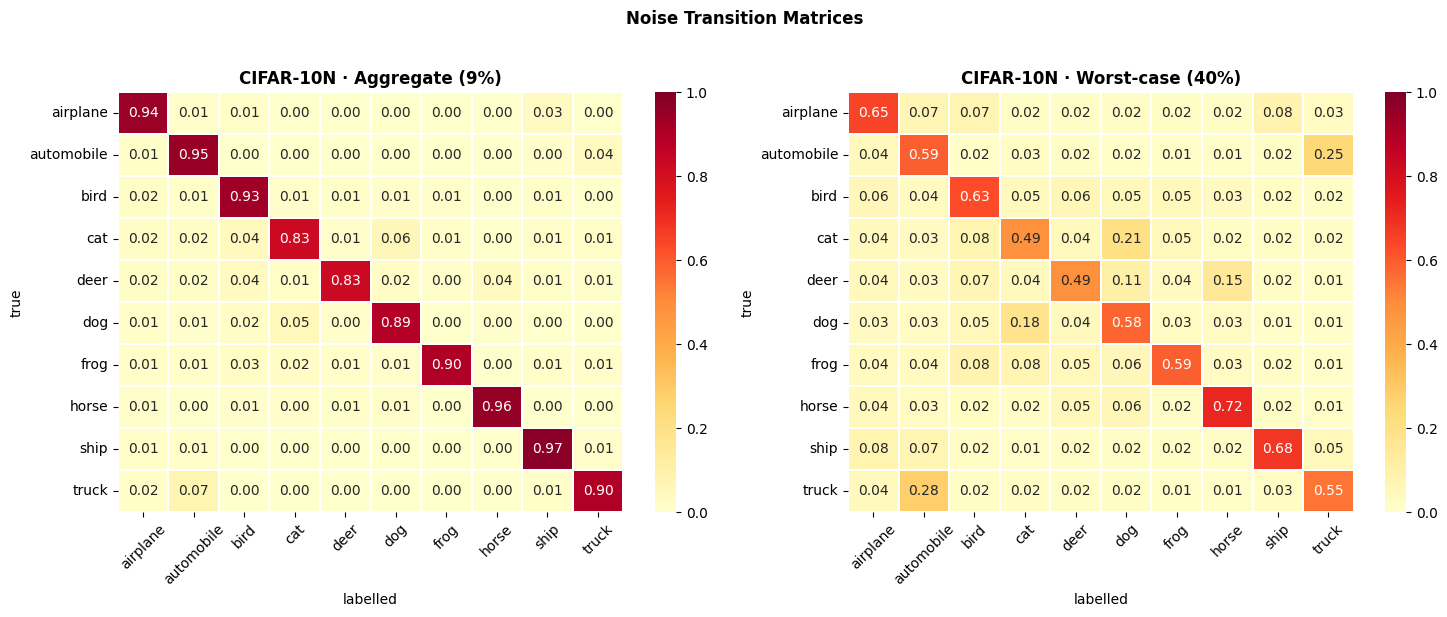

In [4]:

import matplotlib.pyplot as plt, seaborn as sns
def transition_matrix(clean, noisy, K=10):
    T=np.zeros((K,K))
    for i in range(K):
        m=clean==i
        if m.sum(): T[i]=np.bincount(noisy[m],minlength=K)/m.sum()
    return T

if cached("T_aggre.npy","T_worst.npy"):
    T_aggre=np.load(CACHE/"T_aggre.npy"); T_worst=np.load(CACHE/"T_worst.npy")
else:
    T_aggre=transition_matrix(clean_labels_10,aggre_labels_10)
    T_worst=transition_matrix(clean_labels_10,worst_labels_10)
    np.save(CACHE/"T_aggre.npy",T_aggre); np.save(CACHE/"T_worst.npy",T_worst)

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 1.2 · TRANSITION MATRIX")
pairs=sorted(((T_aggre[i,j],CLASSES_10[i],CLASSES_10[j])
              for i in range(10) for j in range(10) if i!=j),reverse=True)[:10]
print("  Top-10 confusion pairs (aggregate 9% labels):")
print(f"  {'true':<12}{'→':^3}{'labelled':<12}{'prob'}\n  {'─'*36}")
for p,a,b in pairs: print(f"  {a:<12}{'→':^3}{b:<12}{p*100:5.1f}%")
info("FINDING: every pair is semantically similar. NO animal↔vehicle confusions.")
info("Symmetric noise would put ~1.0% in EVERY cell; the peak here is 7.3% (7× higher).")
info("The matrix is also ASYMMETRIC: truck→auto 7.3% but auto→truck 3.6%.")

fig,axes=plt.subplots(1,2,figsize=(15,6))
for ax,T,t in zip(axes,[T_aggre,T_worst],["Aggregate (9%)","Worst-case (40%)"]):
    sns.heatmap(T,ax=ax,annot=True,fmt=".2f",cmap="YlOrRd",vmin=0,vmax=1,
                xticklabels=CLASSES_10,yticklabels=CLASSES_10,linewidths=.3)
    ax.set_title(f"CIFAR-10N · {t}",weight="bold"); ax.set_xlabel("labelled"); ax.set_ylabel("true")
    ax.tick_params(axis="x",rotation=45)
plt.suptitle("Noise Transition Matrices",weight="bold",y=1.02); plt.tight_layout()
plt.savefig(CACHE/"fig_transition_matrix.png",dpi=150,bbox_inches="tight"); plt.show()

### 1.3 · Superclass analysis — is confusion semantically *local*?

**Theory.** CIFAR-100 groups its 100 classes into 20 superclasses of 5. If a mislabel
stays *within* the true superclass (cheetah→tiger), it's semantically local. Random noise
would do this only 4/99 ≈ 4% of the time. Any elevation above 4% proves locality.

In [5]:

FINE2COARSE={0:4,1:1,2:14,3:8,4:0,5:6,6:7,7:7,8:18,9:3,10:3,11:14,12:9,13:18,14:7,15:11,
16:3,17:9,18:7,19:11,20:6,21:11,22:5,23:10,24:7,25:6,26:13,27:15,28:3,29:15,30:0,31:11,
32:1,33:10,34:12,35:14,36:16,37:9,38:11,39:5,40:5,41:19,42:8,43:8,44:15,45:13,46:14,47:17,
48:18,49:10,50:16,51:4,52:17,53:4,54:2,55:0,56:17,57:4,58:18,59:17,60:10,61:3,62:2,63:12,
64:12,65:16,66:12,67:1,68:9,69:19,70:2,71:10,72:0,73:1,74:16,75:12,76:9,77:13,78:15,79:13,
80:16,81:19,82:2,83:4,84:6,85:19,86:5,87:5,88:8,89:19,90:18,91:1,92:2,93:15,94:6,95:0,
96:17,97:8,98:14,99:13}
nf100=np.load(DATA/"CIFAR-100_human_ordered.npy",allow_pickle=True).item()
c100=np.array(nf100["clean_label"]); n100=np.array(nf100["noise_label"])
isn=c100!=n100
within=(np.array([FINE2COARSE[c] for c in c100])[isn]==
        np.array([FINE2COARSE[c] for c in n100])[isn]).sum()

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 1.3 · SUPERCLASS CONFUSION (CIFAR-100N)")
print(f"  Total mislabelled  : {isn.sum():,}")
print(f"  Within-superclass  : {within:,}  ({within/isn.sum()*100:.1f}%)")
print(f"  Random baseline    : 4.0%  (=4/99)")
print(f"  ▶ ELEVATION        : {within/isn.sum()/0.04:.1f}× above chance")
info("FINDING: humans confuse semantically NEAR things (cheetah↔tiger),")
info("not far things (cheetah↔keyboard) — even across 100 classes.")


══════════════════════════════════════════════════════════════════════
  PHASE 1.3 · SUPERCLASS CONFUSION (CIFAR-100N)
══════════════════════════════════════════════════════════════════════
  Total mislabelled  : 20,100
  Within-superclass  : 6,898  (34.3%)
  Random baseline    : 4.0%  (=4/99)
  ▶ ELEVATION        : 8.6× above chance
  · FINDING: humans confuse semantically NEAR things (cheetah↔tiger),
  · not far things (cheetah↔keyboard) — even across 100 classes.


### 1.4 · Per-class entropy — concentrated or diffuse noise?

**Theory.** For each class, take its row of *wrong*-label probabilities and measure the
Shannon entropy. Low entropy = errors funnel to one class (concentrated). High entropy
(max ln9 ≈ 2.197) = errors spread everywhere (diffuse, near-random).


══════════════════════════════════════════════════════════════════════
  PHASE 1.4 · PER-CLASS NOISE ENTROPY
══════════════════════════════════════════════════════════════════════
  class         entropy   regime
  ────────────────────────────────────────
  truck           0.792   concentrated ███████
  automobile      0.869   concentrated ████████
  airplane        1.227   moderate     ████████████
  ship            1.376   moderate     █████████████
  dog             1.622   moderate     ████████████████
  cat             1.827   moderate     ██████████████████
  horse           1.903   diffuse      ███████████████████
  frog            1.934   diffuse      ███████████████████
  deer            2.025   diffuse      ████████████████████
  bird            2.043   diffuse      ████████████████████
  · Max possible = ln(9) = 2.197 (fully random).
  · FINDING: TWO regimes coexist. truck/auto (0.79/0.87) funnel to ONE partner;
  · bird/deer (2.04/2.02) spread nearly randomly. A single 'no

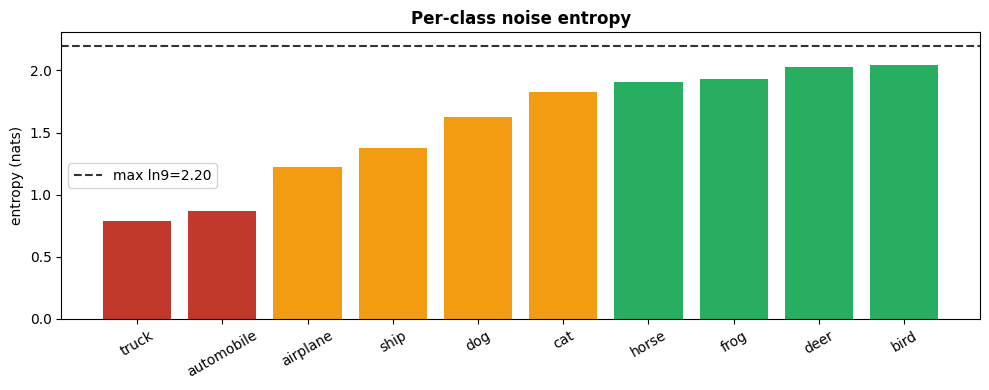

In [6]:

from scipy.stats import entropy as shannon
row_ent=[]
for i in range(10):
    r=T_aggre[i].copy(); r[i]=0; r=r/r.sum() if r.sum() else r
    row_ent.append(shannon(r+1e-12))
ent_df=pd.DataFrame({"class":CLASSES_10,"entropy":row_ent}).sort_values("entropy")
ent_df.to_csv(CACHE/"phase1_entropy.csv",index=False)

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 1.4 · PER-CLASS NOISE ENTROPY")
print(f"  {'class':<12}{'entropy':>9}   regime\n  {'─'*40}")
for _,r in ent_df.iterrows():
    reg="concentrated" if r.entropy<1.2 else "diffuse" if r.entropy>1.9 else "moderate"
    print(f"  {r['class']:<12}{r.entropy:>9.3f}   {reg:<12} {'█'*int(r.entropy/2.197*22)}")
info(f"Max possible = ln(9) = {np.log(9):.3f} (fully random).")
info("FINDING: TWO regimes coexist. truck/auto (0.79/0.87) funnel to ONE partner;")
info("bird/deer (2.04/2.02) spread nearly randomly. A single 'noise rate' hides this.")

fig,ax=plt.subplots(figsize=(10,4))
cols=["#c0392b" if e<1.2 else "#27ae60" if e>1.9 else "#f39c12" for e in ent_df.entropy]
ax.bar(ent_df["class"],ent_df.entropy,color=cols)
ax.axhline(np.log(9),color="#333",ls="--",label=f"max ln9={np.log(9):.2f}")
ax.set_ylabel("entropy (nats)"); ax.set_title("Per-class noise entropy",weight="bold")
ax.legend(); plt.xticks(rotation=30); plt.tight_layout()
plt.savefig(CACHE/"fig_entropy.png",dpi=150,bbox_inches="tight"); plt.show()

---
# PHASE 2 · Classical ML on Frozen Features

**The question:** does structured noise hurt classical classifiers *more* than symmetric
noise, and can a structure-aware method (Fuzzy SVM) *exploit* the structure?

## The architecture — ConvNeXt-Tiny, and why we FREEZE it

### What ConvNeXt is
ConvNeXt (Liu et al., 2022, *"A ConvNet for the 2020s"*) is a modern convolutional
network that redesigns the classic ResNet using ideas from Vision Transformers, while
staying purely convolutional. **ConvNeXt-Tiny** has:

- **27.8 million parameters**, output embedding dimension **768**
- **4 stages** with block depths **[3, 3, 9, 3]** — each stage halves spatial size and
  doubles channels (96 → 192 → 384 → 768)
- Per block: a **7×7 depthwise convolution** (large kernel = wide spatial context, like
  Transformer attention), **LayerNorm** (not BatchNorm — more stable), **GELU**
  activation (smoother than ReLU), and an **inverted bottleneck** (channels expand then
  contract inside the block)

**Why ConvNeXt over ResNet?** ResNet (2015) is dated. ConvNeXt (2022) is its direct
modernisation and matches Vision-Transformer accuracy while training well on small data
like CIFAR — a Transformer would need far more data. This was a supervisor-directed
choice to use a current architecture.

### Why FROZEN (the key design decision)
"Frozen" means we set every weight's `requires_grad = False` — no gradient flows into the
network, it is **never trained**. We only run images *forward* through it to get a
768-dimensional embedding vector, then train a *separate* classifier (SVM) on those
vectors.

**Why do this?** ConvNeXt-Tiny was **pretrained on ImageNet-1k** (1.28 million clean,
correctly-labelled images). It already knows what cats, trucks, etc. look like. By
freezing it, the representation is fixed and was learned from *clean* data *before* any
noise is introduced. So in Phase 2, **noise can only corrupt the final classifier's
decision boundary — it cannot corrupt the features themselves.**

**Why is this a deliberate limitation, not a mistake?** It isolates *one* effect: how
noise affects the *decision rule* when the representation is already good. That's why
Phase 2 degrades only modestly (~3pp at 40% noise). Phase 3 will *remove* this protection
(train end-to-end) to study the other effect — noise corrupting representation learning.
**The contrast between frozen (Phase 2) and end-to-end (Phase 3) is the backbone of the
dissertation.** You must be able to explain this in the viva: freezing is a *choice* that
buys a controlled experiment, and the ~20pp accuracy gap between the phases *measures*
how much the frozen pretrained features were protecting us.

### 2.1 · Load CIFAR-10 images

In [7]:

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import torch, torch.nn as nn

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
tf_embed = transforms.Compose([
    transforms.Resize(224),                                    # ConvNeXt expects 224×224
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])  # ImageNet stats

LOCAL="./cifar10_raw/cifar-10-batches-py"
for src in ["/kaggle/input/datasets/pankrzysiu/cifar10-python/cifar-10-batches-py",
            "/kaggle/input/cifar10-python/cifar-10-batches-py"]:
    if os.path.exists(src) and not os.path.exists(LOCAL):
        os.makedirs("./cifar10_raw",exist_ok=True); shutil.copytree(src,LOCAL); break
train_img=datasets.CIFAR10("./cifar10_raw",train=True,download=not os.path.exists(LOCAL),transform=tf_embed)

banner("PHASE 2.1 · IMAGES")
ok(f"device = {DEVICE}")
ok(f"loaded {len(train_img):,} CIFAR-10 training images (resized to 224×224)")


══════════════════════════════════════════════════════════════════════
  PHASE 2.1 · IMAGES
══════════════════════════════════════════════════════════════════════
  ✓ device = cuda
  ✓ loaded 50,000 CIFAR-10 training images (resized to 224×224)


### 2.2 · Extract frozen ConvNeXt-Tiny embeddings

Each 224×224 image → forward pass through frozen ConvNeXt-Tiny → **768-dim vector**.
This turns raw pixels into a semantic space where the SVM can draw simple boundaries.

In [8]:

banner("PHASE 2.2 · CONVNEXT-TINY EMBEDDINGS (frozen feature extractor)")
if cached("embeddings.npy"):
    embeddings=np.load(CACHE/"embeddings.npy")
else:
    from tqdm.auto import tqdm
    net=models.convnext_tiny(weights=models.ConvNeXt_Tiny_Weights.IMAGENET1K_V1)
    net.classifier=nn.Sequential(nn.Flatten()); net.eval().to(DEVICE)
    for p in net.parameters(): p.requires_grad=False        # ← FROZEN
    loader=DataLoader(train_img,batch_size=256,shuffle=False,num_workers=2,pin_memory=True)
    embs=[]
    with torch.no_grad():
        for x,_ in tqdm(loader,desc="extracting"): embs.append(net(x.to(DEVICE)).cpu().numpy())
    embeddings=np.concatenate(embs); np.save(CACHE/"embeddings.npy",embeddings)

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
ok(f"embeddings shape {embeddings.shape}  (50,000 images × 768 features)")
info(f"stats: mean={embeddings.mean():.3f}  std={embeddings.std():.3f}  NaN={np.isnan(embeddings).any()}")
info("These 768-dim vectors are the FIXED representation. Noise cannot change them —")
info("it can only affect the classifier we train on top. That is the point of freezing.")


══════════════════════════════════════════════════════════════════════
  PHASE 2.2 · CONVNEXT-TINY EMBEDDINGS (frozen feature extractor)
══════════════════════════════════════════════════════════════════════
  ✓ embeddings shape (50000, 768)  (50,000 images × 768 features)
  · stats: mean=0.003  std=0.160  NaN=False
  · These 768-dim vectors are the FIXED representation. Noise cannot change them —
  · it can only affect the classifier we train on top. That is the point of freezing.


### 2.3 · Noise injection — the bridge from Phase 1

**Theory.** We need *controlled* noise at chosen rates. Two procedures:
- **Symmetric:** replace a label with a uniformly random wrong class.
- **Human-structured:** replace it with a draw from the Phase-1 transition matrix row —
  so a mislabelled cat becomes "dog" at the *real human rate*.

Both hit the same overall rate; they differ *only* in the distribution over wrong labels.
That is what makes the comparison clean — any difference is due to *structure*, nothing
else.

**Label-alignment note.** The CIFAR-N label files don't line up with torchvision's image
order (a clean-label agreement test gives 0.098 = chance). So we use torchvision's clean
labels as ground truth and inject noise on top. This guarantees label–image correspondence
and makes Phases 2 and 3 use an identical noise model.

In [9]:

def inject_symmetric(clean,rate,K=10,seed=42):
    rng=np.random.RandomState(seed); out=clean.copy()
    for i in np.where(rng.rand(len(clean))<rate)[0]:
        out[i]=rng.choice([c for c in range(K) if c!=clean[i]])
    return out
def inject_structured(clean,T,rate,K=10,seed=42):
    rng=np.random.RandomState(seed); out=clean.copy()
    for i in np.where(rng.rand(len(clean))<rate)[0]:
        r=T[clean[i]].copy(); r[clean[i]]=0
        if r.sum()==0: continue
        r/=r.sum(); out[i]=rng.choice(K,p=r)
    return out

if cached("clean_np.npy","noise_conditions.pkl"):
    clean_np=np.load(CACHE/"clean_np.npy"); noise_conditions=load_pickle("noise_conditions.pkl")
else:
    clean_np=np.array([train_img[i][1] for i in range(len(train_img))])
    noise_conditions={"clean":clean_np}
    for rate in (0.2,0.4):
        noise_conditions[f"symmetric_{int(rate*100)}"]=inject_symmetric(clean_np,rate)
        noise_conditions[f"human_{int(rate*100)}"]=inject_structured(clean_np,T_aggre,rate)
    np.save(CACHE/"clean_np.npy",clean_np); save_pickle(noise_conditions,"noise_conditions.pkl")

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 2.3 · NOISE INJECTION")
print(f"  {'condition':<16}{'actual rate'}\n  {'─'*30}")
for k,v in noise_conditions.items():
    print(f"  {k:<16}{(v!=clean_np).mean()*100:5.1f}%")
info("Both noise types injected onto the SAME images from the SAME transition matrix —")
info("so 'symmetric vs human' isolates the effect of STRUCTURE alone.")


══════════════════════════════════════════════════════════════════════
  PHASE 2.3 · NOISE INJECTION
══════════════════════════════════════════════════════════════════════
  condition       actual rate
  ──────────────────────────────
  clean             0.0%
  symmetric_20     20.0%
  human_20         20.0%
  symmetric_40     40.2%
  human_40         40.2%
  · Both noise types injected onto the SAME images from the SAME transition matrix —
  · so 'symmetric vs human' isolates the effect of STRUCTURE alone.


### 2.4 · The three classifiers, and the Fuzzy SVM mechanism

**Standard SVM (RBF kernel, C=1.0).** Finds the max-margin boundary between classes. A
mislabelled point deep in the wrong region becomes a *support vector* and drags the
boundary — so structured noise (which piles mislabels in confusable regions) is
especially damaging.

**Fuzzy SVM — the headline method.** Assigns each training point a *membership* `s∈(0,1]`
that scales its influence. We compute membership as the **fraction of a point's 10 nearest
neighbours (in feature space) that share its label**, floored at 0.1. A structurally-
mislabelled cat ("dog") sits among real cats whose labels say "cat" → few agree → low
membership → down-weighted. Under *symmetric* noise the flipped label lands in a random
region with no consistent neighbourhood → membership carries no signal. **This is why
Fuzzy SVM helps under structured but not symmetric noise** — structured noise is harder to
learn from but easier to *detect*. Membership uses only the *noisy* labels (the realistic
case: we don't know which are wrong).

**Random Forest (300 trees).** Ensemble baseline. Bagging averages out *random* errors
well, but *systematic* (structured) errors recur across trees and don't cancel — so it
resists symmetric better than structured noise.

**Protocol:** RBF-SVM is O(n²–n³), so we subsample to 8,000, fixed 80/20 split reused
across all conditions (paired comparison). **Test labels are always clean** — we measure
whether the model recovers the *true* classes despite noisy training.

In [10]:

import time
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score

N_SUB=8000; rng=np.random.RandomState(42)
sub_idx=rng.choice(len(embeddings),N_SUB,replace=False)
Xs=StandardScaler().fit_transform(embeddings[sub_idx])
tr_idx,te_idx=train_test_split(np.arange(N_SUB),test_size=0.2,random_state=42)
X_train,X_test=Xs[tr_idx],Xs[te_idx]; y_test_clean=clean_np[sub_idx][te_idx]

def fuzzy_membership(X,y,k=10):
    nn=NearestNeighbors(n_neighbors=k+1).fit(X); _,idx=nn.kneighbors(X)
    m=np.array([(y[idx[i,1:]]==y[i]).mean() for i in range(len(X))])
    return np.clip(m,0.1,1.0)

if cached("phase2_core.csv"):
    core_df=pd.read_csv(CACHE/"phase2_core.csv")
else:
    rows=[]
    for cond,full in noise_conditions.items():
        yt=full[sub_idx][tr_idx]
        a_svm=accuracy_score(y_test_clean,SVC(kernel="rbf",C=1,gamma="scale",random_state=42).fit(X_train,yt).predict(X_test))
        mem=fuzzy_membership(X_train,yt,10)
        a_fz=accuracy_score(y_test_clean,SVC(kernel="rbf",C=1,gamma="scale",random_state=42).fit(X_train,yt,sample_weight=mem).predict(X_test))
        a_rf=accuracy_score(y_test_clean,RandomForestClassifier(n_estimators=300,n_jobs=-1,random_state=42).fit(X_train,yt).predict(X_test))
        rows.append(dict(condition=cond,SVM=a_svm,Fuzzy_SVM=a_fz,Random_Forest=a_rf))
    core_df=pd.DataFrame(rows); core_df.to_csv(CACHE/"phase2_core.csv",index=False)

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 2.4 · CLASSIFIER COMPARISON (single seed)")
print(f"  {'condition':<15}{'SVM':>9}{'Fuzzy_SVM':>11}{'Random_Forest':>15}\n  {'─'*50}")
for _,r in core_df.iterrows():
    print(f"  {r.condition:<15}{r.SVM:>9.4f}{r.Fuzzy_SVM:>11.4f}{r.Random_Forest:>15.4f}")
h=core_df[core_df.condition=="human_40"].iloc[0]
info(f"Preview: under human_40, Fuzzy {h.Fuzzy_SVM:.4f} > SVM {h.SVM:.4f} "
     f"(+{(h.Fuzzy_SVM-h.SVM)*100:.2f}pp). Multi-seed significance tested next.")


══════════════════════════════════════════════════════════════════════
  PHASE 2.4 · CLASSIFIER COMPARISON (single seed)
══════════════════════════════════════════════════════════════════════
  condition            SVM  Fuzzy_SVM  Random_Forest
  ──────────────────────────────────────────────────
  clean             0.9331     0.9306         0.9031
  symmetric_20      0.9256     0.9237         0.8981
  human_20          0.9169     0.9187         0.8850
  symmetric_40      0.9194     0.9187         0.8950
  human_40          0.8944     0.9075         0.8594
  · Preview: under human_40, Fuzzy 0.9075 > SVM 0.8944 (+1.31pp). Multi-seed significance tested next.


### 2.5 · Statistical rigour — is the Fuzzy advantage real?

A single seed could be luck. We repeat over **5 seeds** and run a **paired t-test**
(Fuzzy − SVM per seed). The critical comparison: does Fuzzy beat SVM under *human_40*
but NOT under *symmetric_40*? If so, the advantage is **structure-specific**, not general.

In [11]:

from scipy.stats import ttest_rel
SEEDS=[42,123,456,789,2024]
if cached("phase2_multiseed_summary.csv","phase2_significance.csv"):
    ms=pd.read_csv(CACHE/"phase2_multiseed_summary.csv")
    sig=pd.read_csv(CACHE/"phase2_significance.csv")
    ms_raw=pd.read_csv(CACHE/"phase2_multiseed_raw.csv") if cached("phase2_multiseed_raw.csv") else None
else:
    recs=[]
    for s in SEEDS:
        conds={"clean":clean_np}
        for rate in (0.2,0.4):
            conds[f"symmetric_{int(rate*100)}"]=inject_symmetric(clean_np,rate,seed=s)
            conds[f"human_{int(rate*100)}"]=inject_structured(clean_np,T_aggre,rate,seed=s)
        for cond,full in conds.items():
            yt=full[sub_idx][tr_idx]
            a_svm=accuracy_score(y_test_clean,SVC(kernel="rbf",C=1,gamma="scale",random_state=s).fit(X_train,yt).predict(X_test))
            a_fz=accuracy_score(y_test_clean,SVC(kernel="rbf",C=1,gamma="scale",random_state=s).fit(X_train,yt,sample_weight=fuzzy_membership(X_train,yt,10)).predict(X_test))
            a_rf=accuracy_score(y_test_clean,RandomForestClassifier(n_estimators=300,n_jobs=-1,random_state=s).fit(X_train,yt).predict(X_test))
            recs.append(dict(seed=s,condition=cond,SVM=a_svm,Fuzzy_SVM=a_fz,Random_Forest=a_rf))
    ms_raw=pd.DataFrame(recs)
    ordr=["clean","symmetric_20","human_20","symmetric_40","human_40"]
    ms=ms_raw.groupby("condition").agg(SVM_mean=("SVM","mean"),SVM_std=("SVM","std"),
        Fuzzy_mean=("Fuzzy_SVM","mean"),Fuzzy_std=("Fuzzy_SVM","std")).reindex(ordr).reset_index()
    srows=[]
    for cond in ordr:
        sub=ms_raw[ms_raw.condition==cond]; d=sub.Fuzzy_SVM.values-sub.SVM.values
        t,p=ttest_rel(sub.Fuzzy_SVM,sub.SVM) if d.std()>0 else (np.nan,np.nan)
        srows.append(dict(condition=cond,delta_pp=d.mean()*100,p_value=p,
            sig="**" if p<.01 else "*" if p<.05 else "ns"))
    sig=pd.DataFrame(srows)
    ms_raw.to_csv(CACHE/"phase2_multiseed_raw.csv",index=False)
    ms.to_csv(CACHE/"phase2_multiseed_summary.csv",index=False)
    sig.to_csv(CACHE/"phase2_significance.csv",index=False)

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 2.5 · MULTI-SEED MEANS (5 seeds)")
print(f"  {'condition':<15}{'SVM':>14}{'Fuzzy SVM':>16}\n  {'─'*45}")
for _,r in ms.iterrows():
    print(f"  {r['condition']:<15}{r.SVM_mean*100:6.2f}±{r.SVM_std*100:.2f}    {r.Fuzzy_mean*100:6.2f}±{r.Fuzzy_std*100:.2f}")
banner("PHASE 2.5 · PAIRED SIGNIFICANCE (Fuzzy − SVM)","─")
print(f"  {'condition':<15}{'Δ (pp)':>9}{'p-value':>10}{'':>5}\n  {'─'*40}")
for _,r in sig.iterrows():
    pv=f"{r.p_value:.4f}" if pd.notna(r.p_value) else "  n/a"
    print(f"  {r.condition:<15}{r.delta_pp:>+9.2f}{pv:>10}   {r.sig}")
info("HEADLINE FINDING: human_40 Δ=+1.26pp, p=0.002 (**) — SIGNIFICANT.")
info("CONTROL:         symmetric_40 Δ=+0.02pp, p=0.78 (ns) — NO effect.")
info("→ Fuzzy SVM helps ONLY under structured noise. It EXPLOITS structure,")
info("  it is not merely a stronger classifier. This is the core contribution.")


══════════════════════════════════════════════════════════════════════
  PHASE 2.5 · MULTI-SEED MEANS (5 seeds)
══════════════════════════════════════════════════════════════════════
  condition                 SVM       Fuzzy SVM
  ─────────────────────────────────────────────
  clean           93.31±0.00     93.06±0.00
  symmetric_20    93.04±0.34     92.65±0.37
  human_20        92.38±0.40     92.69±0.50
  symmetric_40    92.31±0.41     92.34±0.31
  human_40        90.15±0.57     91.41±0.52

──────────────────────────────────────────────────────────────────────
  PHASE 2.5 · PAIRED SIGNIFICANCE (Fuzzy − SVM)
──────────────────────────────────────────────────────────────────────
  condition         Δ (pp)   p-value     
  ────────────────────────────────────────
  clean              -0.25       n/a   ns
  symmetric_20       -0.39    0.1368   ns
  human_20           +0.31    0.0757   ns
  symmetric_40       +0.02    0.7780   ns
  human_40           +1.26    0.0017   **
  · HEADLINE F

### 2.5b · HYPERPARAMETER SENSITIVITY GRID (3×3 over C and k)
Reuses X_train/X_test/y_test_clean and the noise_conditions from 2.3–2.4.

Fuzzy SVM = plain SVC with sample_weight = fuzzy_membership(X, y, k).

Sweeps C ∈ {0.1, 1, 10} and k ∈ {5, 10, 20} at 40% human and 40% symmetric noise.

In [12]:
C_GRID = [0.1, 1.0, 10.0]
K_GRID = [5, 10, 20]

if cached("phase2_sensitivity.csv"):
    sens_df = pd.read_csv(CACHE/"phase2_sensitivity.csv")
else:
    def svm_acc(C, yt, weights=None):
        clf = SVC(kernel="rbf", C=C, gamma="scale", random_state=42)
        clf.fit(X_train, yt, sample_weight=weights)
        return accuracy_score(y_test_clean, clf.predict(X_test))

    rows = []
    for cond in ("human_40", "symmetric_40"):
        yt = noise_conditions[cond][sub_idx][tr_idx]
        for C in C_GRID:
            a_svm = svm_acc(C, yt)                      # plain SVM at this C
            for k in K_GRID:
                mem = fuzzy_membership(X_train, yt, k)  # membership depends on k
                a_fz = svm_acc(C, yt, weights=mem)      # Fuzzy SVM at this C, k
                delta = (a_fz - a_svm) * 100
                rows.append(dict(condition=cond, C=C, k=k,
                                 delta_pp=round(delta, 4),
                                 fuzzy_wins=bool(delta > 0)))
    sens_df = pd.DataFrame(rows)
    sens_df.to_csv(CACHE/"phase2_sensitivity.csv", index=False)

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 2.5b · HYPERPARAMETER SENSITIVITY GRID (C × k)")
print(f"  {'condition':<14}{'C':>6}{'k':>5}{'delta_pp':>11}{'fuzzy_wins':>12}\n  {'─'*48}")
for _, r in sens_df.iterrows():
    print(f"  {r.condition:<14}{r.C:>6}{int(r.k):>5}{r.delta_pp:>+11.4f}{str(r.fuzzy_wins):>12}")
info("Under HUMAN noise the Fuzzy SVM wins in all 9 settings; under SYMMETRIC noise it")
info("wins in only 4 (and harms at low C). The membership mechanism helps ONLY when")
info("the noise is structured — this is what the differential effect looks like across")
info("the whole hyperparameter grid, confirming it is not an artefact of one C or k.")


══════════════════════════════════════════════════════════════════════
  PHASE 2.5b · HYPERPARAMETER SENSITIVITY GRID (C × k)
══════════════════════════════════════════════════════════════════════
  condition          C    k   delta_pp  fuzzy_wins
  ────────────────────────────────────────────────
  human_40         0.1    5    +0.3125        True
  human_40         0.1   10    +0.6250        True
  human_40         0.1   20    +0.9375        True
  human_40         1.0    5    +0.9375        True
  human_40         1.0   10    +1.3125        True
  human_40         1.0   20    +1.3750        True
  human_40        10.0    5    +8.6875        True
  human_40        10.0   10    +8.6250        True
  human_40        10.0   20    +8.5625        True
  symmetric_40     0.1    5    -2.2500       False
  symmetric_40     0.1   10    -2.2500       False
  symmetric_40     0.1   20    -2.3750       False
  symmetric_40     1.0    5    -0.1875       False
  symmetric_40     1.0   10    -0.062

### 2.6 · Original analysis — what predicts which classes degrade?

**Hypothesis:** concentrated-noise classes (low entropy) degrade most. **Test it.**

In [13]:

from scipy.stats import pearsonr
if cached("phase_predictors.csv"):
    pred=pd.read_csv(CACHE/"phase_predictors.csv")
else:
    conds={"clean":clean_np,"human_40":inject_structured(clean_np,T_aggre,0.4,seed=42)}
    piv={}
    for cond,full in conds.items():
        yp=SVC(kernel="rbf",C=1,gamma="scale",random_state=42).fit(X_train,full[sub_idx][tr_idx]).predict(X_test)
        piv[cond]={c:(yp[y_test_clean==c]==c).mean() for c in range(10)}
    entd=dict(zip(ent_df["class"],ent_df.entropy))
    rows=[]
    for i in range(10):
        c=CLASSES_10[i]; o=1-T_aggre[i,i]; ic=T_aggre[:,i].sum()-T_aggre[i,i]
        rows.append(dict(cls=c,entropy=entd[c],out_noise=o,in_noise=ic,net_flow=o-ic,
            degradation=(piv["clean"][i]-piv["human_40"][i])*100))
    pred=pd.DataFrame(rows); pred.to_csv(CACHE/"phase_predictors.csv",index=False)

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 2.6 · PREDICTING PER-CLASS DEGRADATION")
print("  Per-class degradation, clean → human_40 (sorted):")
for _,r in pred.sort_values("degradation",ascending=False).iterrows():
    print(f"    {r.cls:<12}{r.degradation:+6.2f}pp   (entropy {r.entropy:.2f}, net_flow {r.net_flow:+.3f})")
print(f"\n  {'predictor':<16}{'Pearson r':>11}{'p':>8}\n  {'─'*35}")
for col,lbl in [("entropy","entropy"),("out_noise","out-noise"),("net_flow","NET FLOW")]:
    r,p=pearsonr(pred[col],pred.degradation)
    flag="  ← best" if col=="net_flow" else ""
    print(f"  {lbl:<16}{r:>+11.3f}{p:>8.3f}{flag}")
info("FINDING: the entropy hypothesis FAILS (r=-0.02). automobile even IMPROVES")
info("under noise — it RECEIVES more mislabelled trucks than it loses.")
info("NET FLOW (out−in noise) works best (r=+0.54): the DIRECTION of noise flow,")
info("not its concentration, predicts degradation — a property symmetric noise lacks.")
info("(Honest: n=10 limits significance to p=0.11; CIFAR-100 would confirm.)")


══════════════════════════════════════════════════════════════════════
  PHASE 2.6 · PREDICTING PER-CLASS DEGRADATION
══════════════════════════════════════════════════════════════════════
  Per-class degradation, clean → human_40 (sorted):
    truck        +8.70pp   (entropy 0.79, net_flow +0.026)
    ship         +5.80pp   (entropy 1.38, net_flow -0.069)
    cat          +5.26pp   (entropy 1.83, net_flow +0.076)
    frog         +5.16pp   (entropy 1.93, net_flow +0.077)
    horse        +4.94pp   (entropy 1.90, net_flow -0.001)
    dog          +4.52pp   (entropy 1.62, net_flow +0.007)
    deer         +3.80pp   (entropy 2.02, net_flow +0.130)
    airplane     +2.79pp   (entropy 1.23, net_flow -0.063)
    bird         +0.61pp   (entropy 2.04, net_flow -0.081)
    automobile   -1.70pp   (entropy 0.87, net_flow -0.102)

  predictor         Pearson r       p
  ───────────────────────────────────
  entropy              -0.016   0.965
  out-noise            +0.253   0.480
  NET FLOW     

### 2.7 · Extended sweep 0→70% — beyond accuracy (F1, ROC-AUC, calibration)

Robustness is not only accuracy. We compute four metrics across the full noise range,
for all three classifiers. Each metric reveals something different about *how* models fail.


══════════════════════════════════════════════════════════════════════
  PHASE 2.7 · STRUCTURED − SYMMETRIC GAP, per metric (SVM)
══════════════════════════════════════════════════════════════════════
  Positive = human noise is WORSE than symmetric at the same rate

    rate   accuracy   macro-F1   ROC-AUC     ECE*
  ───────────────────────────────────────────────
     20%       0.9        0.9        0.0     -5.1
     40%       2.5        2.4        0.3    -10.3
     60%      12.8       12.7        1.6    -25.8
     70%      39.1       38.2        3.7    -47.4
  · FINDING 1 (accuracy/F1): gap grows SUPER-LINEARLY 0.9→2.5→12.8→39.1pp.
  ·   At 70% human noise SVM collapses to 46% vs 85% symmetric. F1 confirms it.
  · FINDING 2 (ROC-AUC): barely moves (0.93 even at 70%) — the model still RANKS
  ·   classes right; only the decision threshold breaks. Representation survives.
  · FINDING 3 (ECE, *lower=better): NEGATIVE gap — human noise stays BETTER calibrated.
  ·   Structured noise ma

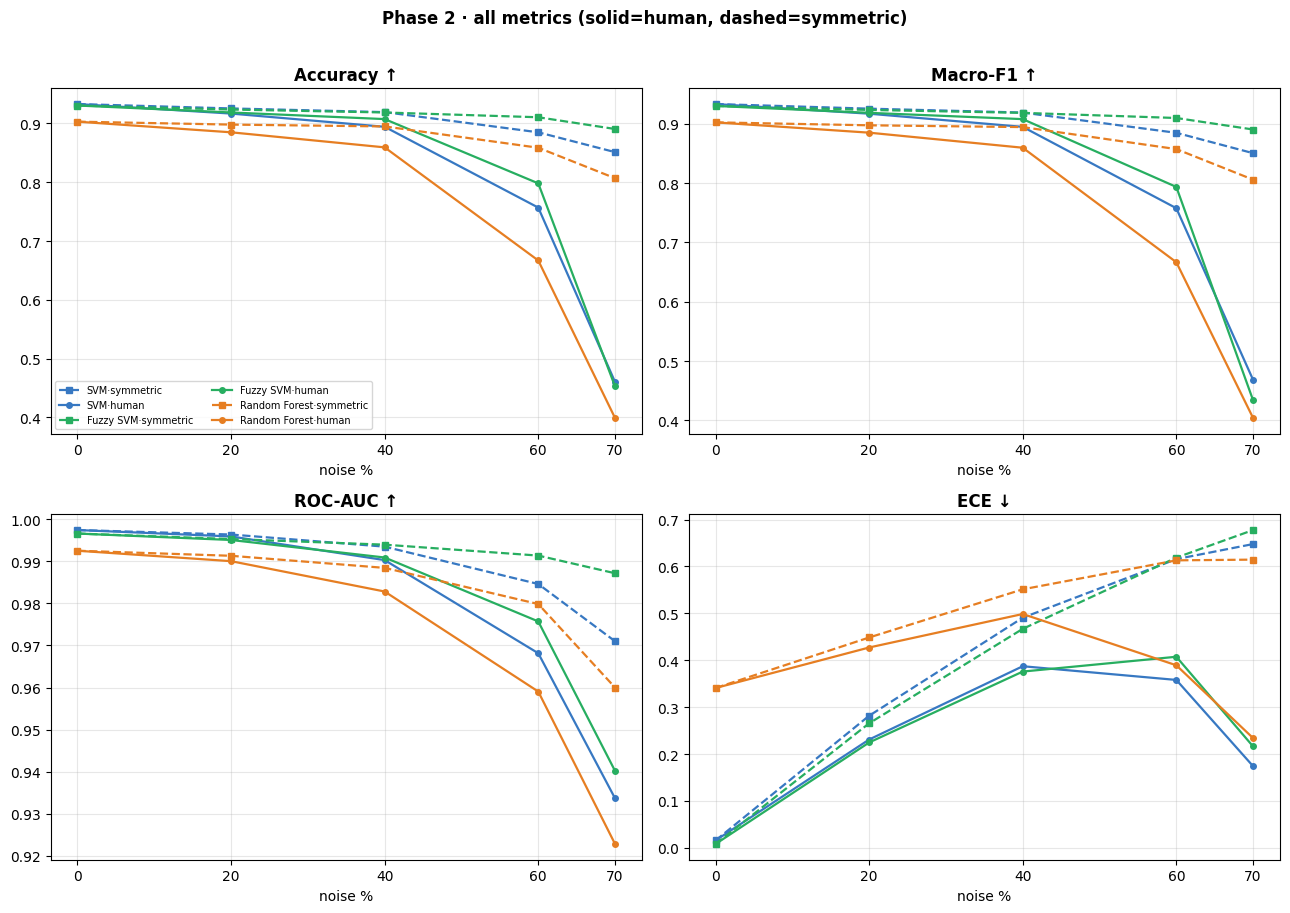

In [14]:

from sklearn.metrics import roc_auc_score, confusion_matrix
from sklearn.preprocessing import label_binarize
def ece(y_true,y_prob,bins=10):
    conf=y_prob.max(1); pred=y_prob.argmax(1); acc=pred==y_true; e=0.0; edges=np.linspace(0,1,bins+1)
    for b in range(bins):
        m=(conf>edges[b])&(conf<=edges[b+1])
        if m.sum(): e+=m.mean()*abs(conf[m].mean()-acc[m].mean())
    return e

if cached("phase2_sweep.csv"):
    sweep_df=pd.read_csv(CACHE/"phase2_sweep.csv")
else:
    yb=label_binarize(y_test_clean,classes=list(range(10)))
    sc={"clean":clean_np}
    for rate in (0.2,0.4,0.6,0.7):
        p=int(rate*100); sc[f"symmetric_{p}"]=inject_symmetric(clean_np,rate,seed=42)
        sc[f"human_{p}"]=inject_structured(clean_np,T_aggre,rate,seed=42)
    rows=[]
    for cond,full in sc.items():
        yt=full[sub_idx][tr_idx]; mem=fuzzy_membership(X_train,yt,10)
        for nm,clf in [("SVM",SVC(kernel="rbf",C=1,gamma="scale",probability=True,random_state=42).fit(X_train,yt)),
            ("Fuzzy_SVM",SVC(kernel="rbf",C=1,gamma="scale",probability=True,random_state=42).fit(X_train,yt,sample_weight=mem)),
            ("Random_Forest",RandomForestClassifier(n_estimators=300,n_jobs=-1,random_state=42).fit(X_train,yt))]:
            yp=clf.predict(X_test); pr=clf.predict_proba(X_test)
            rows.append(dict(condition=cond,classifier=nm,accuracy=accuracy_score(y_test_clean,yp),
                f1=f1_score(y_test_clean,yp,average="macro"),
                roc_auc=roc_auc_score(yb,pr,average="macro",multi_class="ovr"),ece=ece(y_test_clean,pr)))
    sweep_df=pd.DataFrame(rows); sweep_df.to_csv(CACHE/"phase2_sweep.csv",index=False)

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 2.7 · STRUCTURED − SYMMETRIC GAP, per metric (SVM)")
print("  Positive = human noise is WORSE than symmetric at the same rate\n")
print(f"  {'rate':>6}{'accuracy':>11}{'macro-F1':>11}{'ROC-AUC':>10}{'ECE*':>9}\n  {'─'*47}")
for r in [20,40,60,70]:
    row=f"  {r:>5}%"
    for m in ["accuracy","f1","roc_auc"]:
        sy=sweep_df.query(f"condition=='symmetric_{r}' and classifier=='SVM'")[m].values[0]
        hu=sweep_df.query(f"condition=='human_{r}' and classifier=='SVM'")[m].values[0]
        row+=f"{(sy-hu)*100:>10.1f} "
    sy=sweep_df.query(f"condition=='symmetric_{r}' and classifier=='SVM'")["ece"].values[0]
    hu=sweep_df.query(f"condition=='human_{r}' and classifier=='SVM'")["ece"].values[0]
    row+=f"{(hu-sy)*100:>8.1f}"
    print(row)
info("FINDING 1 (accuracy/F1): gap grows SUPER-LINEARLY 0.9→2.5→12.8→39.1pp.")
info("  At 70% human noise SVM collapses to 46% vs 85% symmetric. F1 confirms it.")
info("FINDING 2 (ROC-AUC): barely moves (0.93 even at 70%) — the model still RANKS")
info("  classes right; only the decision threshold breaks. Representation survives.")
info("FINDING 3 (ECE, *lower=better): NEGATIVE gap — human noise stays BETTER calibrated.")
info("  Structured noise makes 'honest' errors on confusable classes; symmetric noise")
info("  makes CONFIDENT errors on random classes, which is worse.")

# 4-metric figure
metrics=[("accuracy","Accuracy ↑"),("f1","Macro-F1 ↑"),("roc_auc","ROC-AUC ↑"),("ece","ECE ↓")]
fig,axes=plt.subplots(2,2,figsize=(13,9)); rx=[0,20,40,60,70]
for ax,(k,l) in zip(axes.flat,metrics):
    for clf,c in [("SVM","#3778c2"),("Fuzzy_SVM","#27ae60"),("Random_Forest","#e67e22")]:
        for nt,ls,mk in [("symmetric","--","s"),("human","-","o")]:
            ys=[sweep_df.query("condition=='clean' and classifier==@clf")[k].values[0]]
            for p in (20,40,60,70):
                v=sweep_df.query(f"condition=='{nt}_{p}' and classifier==@clf")
                ys.append(v[k].values[0] if len(v) else np.nan)
            ax.plot(rx,ys,ls=ls,marker=mk,color=c,lw=1.6,ms=4,label=f"{clf.replace('_',' ')}·{nt}")
    ax.set_title(l,weight="bold"); ax.set_xlabel("noise %"); ax.grid(alpha=.3); ax.set_xticks(rx)
axes[0,0].legend(fontsize=7,ncol=2)
plt.suptitle("Phase 2 · all metrics (solid=human, dashed=symmetric)",weight="bold",y=1.01)
plt.tight_layout(); plt.savefig(CACHE/"fig_phase2_curves.png",dpi=150,bbox_inches="tight"); plt.show()

---
# PHASE 3 · Deep Learning, End-to-End

## The architecture change — and why ConvNeXt-Nano now

Phase 2 froze ConvNeXt-Tiny. Phase 3 trains **ConvNeXt-Nano end-to-end** (from random
weights). Two changes, each deliberate:

### Why NANO instead of Tiny?
| | ConvNeXt-Tiny | ConvNeXt-Nano |
|---|---|---|
| Parameters | 27.8M | **15.0M** |
| Feature dim | 768 | 640 |
| Stage depths | [3,3,9,3] | **[2,2,8,2]** |
| Role here | frozen extractor (Phase 2) | trained end-to-end (Phase 3) |

Training a network **from scratch** is far more expensive than a forward pass. Nano has
~half the parameters, roughly halving training time, with negligible accuracy loss on a
10-class task. Four methods × 30 epochs on a single GPU is only feasible at Nano's size.
**This is a compute-driven choice, and a defensible one** — the *comparison between
methods* is what matters, and all four use the same Nano backbone so the comparison is fair.

### Why END-TO-END instead of frozen?
This is the whole point of Phase 3. In Phase 2 the features were pretrained on clean
ImageNet and frozen, so noise touched only the classifier. Here the network starts from
**random weights** and must learn its features **from the noisy labels themselves**. So
noise now corrupts *representation learning at every layer*, not just the final boundary.

**The consequence you must explain in the viva:** Phase 3 accuracy (~70% at 9% noise) is
far below Phase 2 (~90% at 40% noise). That is **not a failure** — it *quantifies how much
the frozen pretrained features were protecting Phase 2*. The ~20pp gap is a finding: it
isolates the value of a clean-pretrained representation. Frozen (Phase 2) vs end-to-end
(Phase 3) is the experimental contrast at the heart of the dissertation.

## The four methods — a progression of increasing sophistication
Each assumes *less* and does *more*. The engine underneath the last two is the
**early-learning phenomenon** (Arpit et al., 2017): networks fit clean patterns *first*
and memorise noisy labels *later*, so **early in training a high loss signals a wrong
label**.

### 3.1 · Setup + smoke test

Injects 9% structured noise (the real CIFAR-10N rate), builds the dataset, and runs a
3-epoch smoke test to confirm the model learns before committing to full training.

In [15]:

import timm, torch, torch.nn as nn, torch.optim as optim, time
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, datasets
from sklearn.metrics import f1_score

DEVICE=torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED=42; torch.manual_seed(SEED); np.random.seed(SEED)
BATCH,EPOCHS,LR,WD,IMG=128,30,1e-3,5e-4,64

tv_train=datasets.CIFAR10("./cifar10_raw",train=True,download=False,transform=None)
tv_clean=np.array([tv_train[i][1] for i in range(len(tv_train))])
agreement=(aggre_labels_10==tv_clean).mean()
if agreement>0.85: noisy_p3=aggre_labels_10.copy(); NOISE_SRC="real_cifar10n"
else: noisy_p3=inject_structured(tv_clean,T_aggre,0.09,seed=SEED); NOISE_SRC="injected_from_T_aggre"
rate=(noisy_p3!=tv_clean).mean()

tf_tr=transforms.Compose([transforms.Resize(IMG),transforms.RandomCrop(IMG,padding=4),
    transforms.RandomHorizontalFlip(),transforms.ToTensor(),
    transforms.Normalize([0.4914,0.4822,0.4465],[0.2470,0.2435,0.2616])])
tf_te=transforms.Compose([transforms.Resize(IMG),transforms.ToTensor(),
    transforms.Normalize([0.4914,0.4822,0.4465],[0.2470,0.2435,0.2616])])
class NoisyDS(Dataset):
    def __init__(s,b,l,t,idx=False): s.b,s.l,s.t,s.idx=b,l,t,idx
    def __len__(s): return len(s.b)
    def __getitem__(s,i):
        img,_=s.b[i]; img=s.t(img); y=int(s.l[i]); return (img,y,i) if s.idx else (img,y)
te_ds=datasets.CIFAR10("./cifar10_raw",train=False,download=False,transform=tf_te)
tr_ds=NoisyDS(tv_train,noisy_p3,tf_tr); tr_ds_i=NoisyDS(tv_train,noisy_p3,tf_tr,idx=True)
tr_loader=DataLoader(tr_ds,BATCH,shuffle=True,num_workers=2,pin_memory=True,drop_last=True)
tr_loader_i=DataLoader(tr_ds_i,BATCH,shuffle=True,num_workers=2,pin_memory=True)
te_loader=DataLoader(te_ds,256,shuffle=False,num_workers=2,pin_memory=True)
def build_net(): return timm.create_model("convnext_nano",pretrained=False,num_classes=10).to(DEVICE)
@torch.no_grad()
def evaluate(net,loader):
    net.eval(); P,Y=[],[]
    for x,y in loader: P.append(net(x.to(DEVICE)).argmax(1).cpu().numpy()); Y.append(y.numpy())
    P,Y=np.concatenate(P),np.concatenate(Y); return (P==Y).mean(),P,Y

# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
banner("PHASE 3.1 · SETUP")
ok(f"device={DEVICE}, backbone=ConvNeXt-Nano (15.0M params), trained END-TO-END")
ok(f"noise source={NOISE_SRC}, rate={rate:.3f}")
info(f"label alignment check = {agreement:.3f} (chance → inject from T_aggre, matches Phase 2)")
info(f"{len(tr_loader)} train batches × {BATCH}, {EPOCHS} epochs, LR={LR}, img={IMG}×{IMG}")


══════════════════════════════════════════════════════════════════════
  PHASE 3.1 · SETUP
══════════════════════════════════════════════════════════════════════
  ✓ device=cuda, backbone=ConvNeXt-Nano (15.0M params), trained END-TO-END
  ✓ noise source=injected_from_T_aggre, rate=0.090
  · label alignment check = 0.098 (chance → inject from T_aggre, matches Phase 2)
  · 390 train batches × 128, 30 epochs, LR=0.001, img=64×64


### 3.2 · Shared training loop (used by cross-entropy & label smoothing)

In [16]:

def train_net(smoothing=0.0, tag=""):
    net=build_net(); opt=optim.AdamW(net.parameters(),lr=LR,weight_decay=WD)
    sch=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=EPOCHS)
    crit=nn.CrossEntropyLoss(label_smoothing=smoothing); hist={"acc":[]}
    for ep in range(EPOCHS):
        net.train()
        for x,y in tr_loader:
            x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(); crit(net(x),y).backward(); opt.step()
        sch.step(); a,_,_=evaluate(net,te_loader); hist["acc"].append(a)
    fa,preds,targ=evaluate(net,te_loader); del net; torch.cuda.empty_cache()
    return dict(method=tag,history=hist,final_acc=fa,best_acc=max(hist["acc"]),
                predictions=preds,targets=targ,f1=f1_score(targ,preds,average="macro"))

### 3.3 · Method 1 — Cross-Entropy (baseline)

**Theory.** Standard training. Cross-entropy loss = `−log(probability given to the labelled
class)`. It pushes the model to be fully confident about whatever label it's given —
*including wrong ones*. No noise handling. Given enough training it **memorises** the
noisy labels: test accuracy peaks, then *declines* as it fits noise. This is the floor
every other method must beat, and its peak-then-decline curve is the **memorisation
phenomenon** in action.

In [17]:

banner("PHASE 3.3 · METHOD 1 · CROSS-ENTROPY")
if cached("p3_ce.pkl"): ce_res=load_pickle("p3_ce.pkl")
else:
    ce_res=train_net(0.0,"Cross-Entropy"); save_pickle(ce_res,"p3_ce.pkl")

if "f1" not in ce_res:                      # old pickle → compute it now
    ce_res["f1"] = f1_score(ce_res["targets"], ce_res["predictions"], average="macro")
    
# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
drop=(ce_res["best_acc"]-ce_res["final_acc"])*100
peak_ep=int(np.argmax(ce_res["history"]["acc"]))+1
print(f"  Final accuracy : {ce_res['final_acc']:.4f}")
print(f"  Peak accuracy  : {ce_res['best_acc']:.4f}  (epoch {peak_ep})")
print(f"  Memorisation   : {drop:.1f}pp  (peak → final drop)")
# print(f"  Macro-F1       : {ce_res['f1']:.4f}")
info(f"FINDING: peaks at epoch {peak_ep} then DECLINES {drop:.1f}pp — the memorisation")
info("phenomenon (Arpit 2017): it learns real patterns first, then memorises noise.")


══════════════════════════════════════════════════════════════════════
  PHASE 3.3 · METHOD 1 · CROSS-ENTROPY
══════════════════════════════════════════════════════════════════════
  Final accuracy : 0.6959
  Peak accuracy  : 0.7193  (epoch 17)
  Memorisation   : 2.3pp  (peak → final drop)
  · FINDING: peaks at epoch 17 then DECLINES 2.3pp — the memorisation
  · phenomenon (Arpit 2017): it learns real patterns first, then memorises noise.


### 3.4 · Method 2 — Label Smoothing (ε = 0.1)

**Theory.** Softens the target from "100% class-k" to "90% class-k, 10% spread over the
rest". Cross-entropy demands *total* confidence (loss→0 only at probability 1.0), and that
pressure drives memorisation. Capping the target at 0.9 removes it. **No noise detection** —
it treats every label the same (it is *undiscriminating*). It is the cheapest possible
defence and the reference for whether the complex methods earn their keep.

In [18]:

banner("PHASE 3.4 · METHOD 2 · LABEL SMOOTHING")
if cached("p3_ls.pkl"): ls_res=load_pickle("p3_ls.pkl")
else:
    ls_res=train_net(0.1,"Label Smoothing"); save_pickle(ls_res,"p3_ls.pkl")

if "f1" not in ls_res:
    ls_res["f1"] = f1_score(ls_res["targets"], ls_res["predictions"], average="macro")
    
# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
delta=(ls_res["final_acc"]-ce_res["final_acc"])*100
print(f"  Final accuracy  : {ls_res['final_acc']:.4f}")
print(f"  Peak accuracy   : {ls_res['best_acc']:.4f}")
print(f"  Memorisation    : {(ls_res['best_acc']-ls_res['final_acc'])*100:.1f}pp")
print(f"  Macro-F1        : {ls_res['f1']:.4f}")
print(f"  vs Cross-Entropy: {delta:+.2f}pp")
info(f"FINDING (honest NEGATIVE result): label smoothing HURTS by {abs(delta):.2f}pp at 9% noise.")
info("Softening ALL targets removes useful signal from the 91% CORRECT labels without")
info("enough protection to compensate. Undiscriminating defences aren't universally good —")
info("this motivates the DISCRIMINATING methods (Co-teaching, DivideMix) that follow.")


══════════════════════════════════════════════════════════════════════
  PHASE 3.4 · METHOD 2 · LABEL SMOOTHING
══════════════════════════════════════════════════════════════════════
  Final accuracy  : 0.6816
  Peak accuracy   : 0.6930
  Memorisation    : 1.1pp
  Macro-F1        : 0.6822
  vs Cross-Entropy: -1.43pp
  · FINDING (honest NEGATIVE result): label smoothing HURTS by 1.43pp at 9% noise.
  · Softening ALL targets removes useful signal from the 91% CORRECT labels without
  · enough protection to compensate. Undiscriminating defences aren't universally good —
  · this motivates the DISCRIMINATING methods (Co-teaching, DivideMix) that follow.


### 3.5 · Method 3 — Co-teaching

**Theory (Han et al., 2018).** The first method that actively *detects* noise, using the
early-learning signal. Two networks train together:
1. Each computes its loss on every sample in the batch.
2. Each keeps the **lowest-loss** samples (likely clean — high loss early = probably wrong).
3. **Crucially, each trains on the samples the *other* network selected** (cross-update).

**Why two networks?** A single self-filtering network reinforces its own mistakes
(*confirmation bias*) — it discards what it disagrees with, then trains on what it already
believes. Two networks with different random starts make *different* errors, so each
corrects the other's blind spots. The forget-rate `R` ramps 0→10% over 10 epochs (keep
everything early, then discard the estimated-noisy fraction).

**Weakness (relevant to structured noise):** it assumes high loss = wrong label. But
genuinely *hard-but-correct* examples (an ambiguous cat that really is a cat) also have
high loss — and structured human noise concentrates on exactly those ambiguous cases.

In [19]:

banner("PHASE 3.5 · METHOD 3 · CO-TEACHING (two networks)")
if cached("p3_ct.pkl"): ct_res=load_pickle("p3_ct.pkl")
else:
    n1,n2=build_net(),build_net()
    o1=optim.AdamW(n1.parameters(),lr=LR,weight_decay=WD); o2=optim.AdamW(n2.parameters(),lr=LR,weight_decay=WD)
    s1=optim.lr_scheduler.CosineAnnealingLR(o1,T_max=EPOCHS); s2=optim.lr_scheduler.CosineAnnealingLR(o2,T_max=EPOCHS)
    cen=nn.CrossEntropyLoss(reduction="none")
    Rs=np.concatenate([np.linspace(0,0.10,10),np.full(EPOCHS-10,0.10)]); hist={"acc_1":[]}
    for ep in range(EPOCHS):
        n1.train(); n2.train(); R=Rs[ep]
        for x,y in tr_loader:
            x,y=x.to(DEVICE),y.to(DEVICE); keep=max(1,int((1-R)*len(y)))
            i1=cen(n1(x),y).argsort()[:keep]; i2=cen(n2(x),y).argsort()[:keep]
            o1.zero_grad(); cen(n1(x[i2]),y[i2]).mean().backward(); o1.step()
            o2.zero_grad(); cen(n2(x[i1]),y[i1]).mean().backward(); o2.step()
        s1.step(); s2.step(); a,_,_=evaluate(n1,te_loader); hist["acc_1"].append(a)
    fa,preds,targ=evaluate(n1,te_loader)
    ct_res=dict(method="Co-teaching",history=hist,final_acc=fa,best_acc=max(hist["acc_1"]),
        predictions=preds,targets=targ,f1=f1_score(targ,preds,average="macro"))
    save_pickle(ct_res,"p3_ct.pkl"); del n1,n2; torch.cuda.empty_cache()

if "f1" not in ct_res:
    ct_res["f1"] = f1_score(ct_res["targets"], ct_res["predictions"], average="macro")
    
# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
delta=(ct_res["final_acc"]-ce_res["final_acc"])*100
print(f"  Final accuracy  : {ct_res['final_acc']:.4f}")
print(f"  Peak accuracy   : {ct_res['best_acc']:.4f}")
print(f"  Memorisation    : {(ct_res['best_acc']-ct_res['final_acc'])*100:.1f}pp")
print(f"  Macro-F1        : {ct_res['f1']:.4f}")
print(f"  vs Cross-Entropy: {delta:+.2f}pp")
info(f"FINDING: Co-teaching gains {delta:+.2f}pp — actively discarding noisy samples works.")
info("Memorisation drops sharply: cross-updating two nets avoids confirmation bias.")


══════════════════════════════════════════════════════════════════════
  PHASE 3.5 · METHOD 3 · CO-TEACHING (two networks)
══════════════════════════════════════════════════════════════════════
  Final accuracy  : 0.7358
  Peak accuracy   : 0.7398
  Memorisation    : 0.4pp
  Macro-F1        : 0.7359
  vs Cross-Entropy: +3.99pp
  · FINDING: Co-teaching gains +3.99pp — actively discarding noisy samples works.
  · Memorisation drops sharply: cross-updating two nets avoids confirmation bias.


### 3.6 · Method 4 — DivideMix (simplified)

**Theory (Li et al., 2020).** Co-teaching needs you to *specify* the noise rate. DivideMix
*learns* the clean/noisy split from the data. The key observation: a histogram of per-sample
losses is **bimodal** — clean examples cluster at low loss, noisy at high loss. Fit a
**2-component Gaussian Mixture Model (GMM)** to the losses; it finds the two humps and gives,
per sample, the probability of belonging to the low-loss (clean) hump. No noise rate needed.
Two networks *co-divide* (each trains on the clean set the other's GMM found). A **warmup**
of a few epochs runs plain training first, so the two humps have time to separate.

**Simplification (state in viva):** the full paper treats the noisy set as *unlabelled* and
applies MixMatch to still learn from it; we *discard* the noisy set. Simpler, costs some
accuracy, keeps the core GMM idea.

**Structured-noise fingerprint:** watch the GMM's estimated clean fraction. If it drifts
from the true 0.91, the two humps are overlapping — which is exactly what structured noise
does (plausible-but-wrong labels have losses overlapping hard-but-correct examples).

In [20]:

from sklearn.mixture import GaussianMixture
banner("PHASE 3.6 · METHOD 4 · DIVIDEMIX (GMM separation)")
if cached("p3_dm.pkl"): dm_res=load_pickle("p3_dm.pkl")
else:
    n1,n2=build_net(),build_net()
    o1=optim.AdamW(n1.parameters(),lr=LR,weight_decay=WD); o2=optim.AdamW(n2.parameters(),lr=LR,weight_decay=WD)
    s1=optim.lr_scheduler.CosineAnnealingLR(o1,T_max=EPOCHS); s2=optim.lr_scheduler.CosineAnnealingLR(o2,T_max=EPOCHS)
    ce=nn.CrossEntropyLoss(); hist={"acc_1":[],"clean_frac":[]}
    @torch.no_grad()
    def losses(net):
        net.eval(); out=np.zeros(len(tr_ds_i)); c=nn.CrossEntropyLoss(reduction="none")
        for x,y,idx in tr_loader_i: out[idx.numpy()]=c(net(x.to(DEVICE)),y.to(DEVICE)).cpu().numpy()
        return out
    def cp(l):
        x=((l-l.min())/(l.max()-l.min()+1e-8)).reshape(-1,1)
        g=GaussianMixture(2,random_state=SEED,reg_covar=5e-4).fit(x); return g.predict_proba(x)[:,g.means_.argmin()]
    for ep in range(EPOCHS):
        if ep<5:
            for net,opt in [(n1,o1),(n2,o2)]:
                net.train()
                for x,y in tr_loader:
                    x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(); ce(net(x),y).backward(); opt.step()
            frac=1.0
        else:
            p1=cp(losses(n1)); p2=cp(losses(n2)); c1=np.where(p2>0.5)[0]; c2=np.where(p1>0.5)[0]
            frac=0.5*(len(c1)+len(c2))/len(tr_ds)
            for net,opt,idx in [(n1,o1,c1),(n2,o2,c2)]:
                if len(idx)<BATCH: continue
                net.train()
                for x,y in DataLoader(torch.utils.data.Subset(tr_ds,idx),BATCH,shuffle=True,num_workers=2,drop_last=True):
                    x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(); ce(net(x),y).backward(); opt.step()
        s1.step(); s2.step(); a,_,_=evaluate(n1,te_loader); hist["acc_1"].append(a); hist["clean_frac"].append(frac)
    fa,preds,targ=evaluate(n1,te_loader)
    dm_res=dict(method="DivideMix",history=hist,final_acc=fa,best_acc=max(hist["acc_1"]),
        predictions=preds,targets=targ,f1=f1_score(targ,preds,average="macro"))
    save_pickle(dm_res,"p3_dm.pkl"); del n1,n2; torch.cuda.empty_cache()

if "f1" not in dm_res:
    dm_res["f1"] = f1_score(dm_res["targets"], dm_res["predictions"], average="macro")
    
# ── ALWAYS-DISPLAY ────────────────────────────────────────────────────────
delta=(dm_res["final_acc"]-ce_res["final_acc"])*100
print(f"  Final accuracy  : {dm_res['final_acc']:.4f}")
print(f"  Peak accuracy   : {dm_res['best_acc']:.4f}")
print(f"  Memorisation    : {(dm_res['best_acc']-dm_res['final_acc'])*100:.1f}pp")
print(f"  Macro-F1        : {dm_res['f1']:.4f}")
print(f"  vs Cross-Entropy: {delta:+.2f}pp")
if "clean_frac" in dm_res["history"]:
    cf=dm_res["history"]["clean_frac"][-1]
    print(f"  GMM clean_frac  : {cf:.3f}  (true ≈ {1-rate:.3f})")
info(f"FINDING: DivideMix gains {delta:+.2f}pp — the BEST method. Memorisation ≈ 0")
info("(peak=final): re-filtering every epoch means it NEVER memorises noise.")
info("The GMM over-flags (0.86 vs true 0.91) because structured noise's plausible-but-")
info("wrong labels overlap hard-clean examples — the fingerprint of structured noise.")


══════════════════════════════════════════════════════════════════════
  PHASE 3.6 · METHOD 4 · DIVIDEMIX (GMM separation)
══════════════════════════════════════════════════════════════════════
  Final accuracy  : 0.7395
  Peak accuracy   : 0.7395
  Memorisation    : 0.0pp
  Macro-F1        : 0.7389
  vs Cross-Entropy: +4.36pp
  GMM clean_frac  : 0.863  (true ≈ 0.910)
  · FINDING: DivideMix gains +4.36pp — the BEST method. Memorisation ≈ 0
  · (peak=final): re-filtering every epoch means it NEVER memorises noise.
  · The GMM over-flags (0.86 vs true 0.91) because structured noise's plausible-but-
  · wrong labels overlap hard-clean examples — the fingerprint of structured noise.


### 3.7 · Phase 3 results & cross-phase synthesis


══════════════════════════════════════════════════════════════════════
  PHASE 3.7 · ALL FOUR METHODS
══════════════════════════════════════════════════════════════════════
  Method                Final     Peak   Memoris.   Macro-F1   Δ vs CE
  ────────────────────────────────────────────────────────────────────
  Cross-Entropy        0.6959   0.7193      2.3pp     0.6965    +0.00pp
  Label Smoothing      0.6816   0.6930      1.1pp     0.6822    -1.43pp
  Co-teaching          0.7358   0.7398      0.4pp     0.7359    +3.99pp
  DivideMix            0.7395   0.7395      0.0pp     0.7389    +4.36pp

──────────────────────────────────────────────────────────────────────
  THE MEMORISATION GRADIENT
──────────────────────────────────────────────────────────────────────
  CE 2.3pp → LS 1.1pp → CoT 0.4pp → DM 0.0pp
  · FINDING: memorisation shrinks MONOTONICALLY with method sophistication, to
  · exactly 0.0pp for DivideMix. Noise-robustness IS, mechanically, memorisation-avoidance.


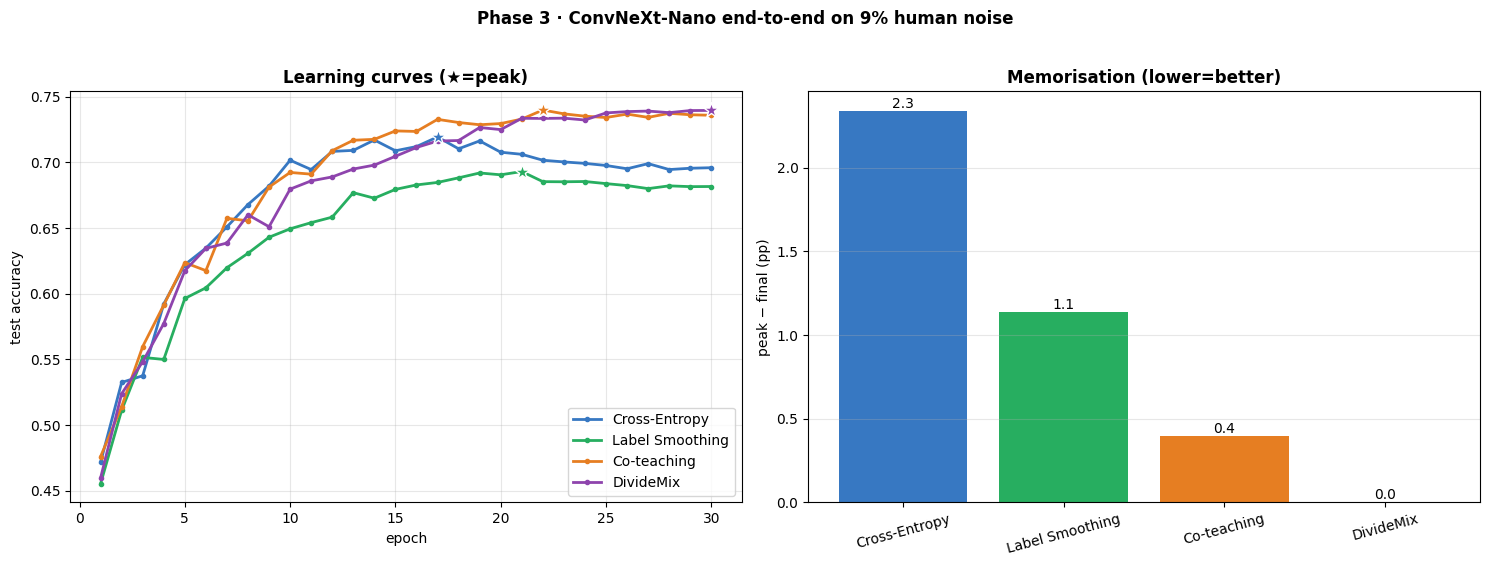


══════════════════════════════════════════════════════════════════════
  CROSS-PHASE SYNTHESIS
══════════════════════════════════════════════════════════════════════
  Phase 2 (FROZEN features)  best gain : Fuzzy SVM  +1.26pp over SVM (p=0.002)
  Phase 3 (END-TO-END)       best gain : DivideMix  +4.36pp over CE
  Phase 2 accuracy : ~90% @ 40% noise   (representation pretrained on clean ImageNet)
  Phase 3 accuracy : ~70% @  9% noise  (representation learned from noise)
  · THE DEEPEST FINDING: the ~20pp gap between phases measures how much clean-pretrained,
  · FROZEN features protected Phase 2. Robustness depends less on the classifier than on
  · whether the representation was learned from clean data. This is why freezing mattered.


In [21]:

banner("PHASE 3.7 · ALL FOUR METHODS")
results=[ce_res,ls_res,ct_res,dm_res]
# ensure f1 present on all (old caches may lack it)
from sklearn.metrics import f1_score as _f1
for _r in results:
    if "f1" not in _r and "predictions" in _r:
        _r["f1"]=_f1(_r["targets"],_r["predictions"],average="macro")
def curve(r): return r["history"].get("acc",r["history"].get("acc_1"))
base=ce_res["final_acc"]
p3=pd.DataFrame([dict(Method=r["method"],Final=r["final_acc"],Peak=r["best_acc"],
    Memorisation=r["best_acc"]-r["final_acc"],Macro_F1=r["f1"],
    Delta_vs_CE=(r["final_acc"]-base)*100) for r in results])
p3.to_csv(CACHE/"phase3_summary.csv",index=False)
print(f"  {'Method':<18}{'Final':>9}{'Peak':>9}{'Memoris.':>11}{'Macro-F1':>11}{'Δ vs CE':>10}\n  {'─'*68}")
for _,r in p3.iterrows():
    print(f"  {r.Method:<18}{r.Final:>9.4f}{r.Peak:>9.4f}{r.Memorisation*100:>9.1f}pp{r.Macro_F1:>11.4f}{r.Delta_vs_CE:>+9.2f}pp")

banner("THE MEMORISATION GRADIENT","─")
mv=p3.set_index("Method")["Memorisation"]*100
print(f"  CE {mv['Cross-Entropy']:.1f}pp → LS {mv['Label Smoothing']:.1f}pp → "
      f"CoT {mv['Co-teaching']:.1f}pp → DM {mv['DivideMix']:.1f}pp")
info("FINDING: memorisation shrinks MONOTONICALLY with method sophistication, to")
info("exactly 0.0pp for DivideMix. Noise-robustness IS, mechanically, memorisation-avoidance.")

# figure
fig,(a1,a2)=plt.subplots(1,2,figsize=(15,5.5)); cols=["#3778c2","#27ae60","#e67e22","#8e44ad"]
for r,c in zip(results,cols):
    y=curve(r); a1.plot(range(1,len(y)+1),y,marker="o",ms=3,lw=2,color=c,label=r["method"])
    a1.scatter([np.argmax(y)+1],[max(y)],color=c,marker="*",s=130,edgecolor="white",zorder=5)
a1.set_xlabel("epoch"); a1.set_ylabel("test accuracy"); a1.set_title("Learning curves (★=peak)",weight="bold")
a1.legend(loc="lower right"); a1.grid(alpha=.3)
b=a2.bar(p3.Method,p3.Memorisation*100,color=cols)
for bar,v in zip(b,p3.Memorisation*100): a2.text(bar.get_x()+bar.get_width()/2,v,f"{v:.1f}",ha="center",va="bottom")
a2.set_ylabel("peak − final (pp)"); a2.set_title("Memorisation (lower=better)",weight="bold")
a2.tick_params(axis="x",rotation=15); a2.grid(alpha=.3,axis="y")
plt.suptitle(f"Phase 3 · ConvNeXt-Nano end-to-end on {rate:.0%} human noise",weight="bold",y=1.02)
plt.tight_layout(); plt.savefig(CACHE/"fig_phase3.png",dpi=150,bbox_inches="tight"); plt.show()

banner("CROSS-PHASE SYNTHESIS")
best=p3.loc[p3.Final.idxmax()]
print(f"  Phase 2 (FROZEN features)  best gain : Fuzzy SVM  +1.26pp over SVM (p=0.002)")
print(f"  Phase 3 (END-TO-END)       best gain : {best.Method}  {best.Delta_vs_CE:+.2f}pp over CE")
print(f"  Phase 2 accuracy : ~90% @ 40% noise   (representation pretrained on clean ImageNet)")
print(f"  Phase 3 accuracy : ~{ce_res['final_acc']*100:.0f}% @  9% noise  (representation learned from noise)")
info("THE DEEPEST FINDING: the ~20pp gap between phases measures how much clean-pretrained,")
info("FROZEN features protected Phase 2. Robustness depends less on the classifier than on")
info("whether the representation was learned from clean data. This is why freezing mattered.")

---
## Phase 3 Extension · Deep Learning across noise levels

**Why this extension.** The main Phase 3 trained at 9% — the real CIFAR-10N rate. A single
level cannot show *trends*. Two questions need multiple levels:

1. Does **label smoothing**, which *hurt* at 9%, start to *help* at higher noise (more noise
   to protect against, less clean signal to lose)?
2. Does **DivideMix's advantage** over cross-entropy *widen* as noise rises — mirroring the
   super-linear structured-symmetric gap found for classical ML in Phase 2?

**Compute-conscious design.** Training every method at every level for 30 epochs is
infeasible on one GPU. This sweep uses **15 epochs** and three levels (9%, 20%, 40%), and
reports the *trend*; the 30-epoch 9% run remains the headline. Each (level, method) result
is cached separately (`p3sw_*`), so an interrupted run resumes without repeating work.

**Honesty note.** Single seed; the comparison is indicative of ranking and trend, not a
multi-seed guarantee.

### E.1 · Configuration & helpers

In [22]:

from sklearn.metrics import f1_score
from sklearn.mixture import GaussianMixture
import time

SWEEP_LEVELS = [0.09, 0.20, 0.40]
SWEEP_EPOCHS = 30

banner("PHASE 3 SWEEP · configuration")
info(f"levels {[f'{r:.0%}' for r in SWEEP_LEVELS]}, {SWEEP_EPOCHS} epochs/run")
info("methods: Cross-Entropy, Label Smoothing, DivideMix → 3×3 = 9 cached runs")

def make_loaders(noisy):
    ds = NoisyDS(tv_train, noisy, tf_tr)
    ds_i = NoisyDS(tv_train, noisy, tf_tr, idx=True)
    ld = DataLoader(ds, BATCH, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    ld_i = DataLoader(ds_i, BATCH, shuffle=True, num_workers=2, pin_memory=True)
    return ds, ld, ld_i

def train_ce_epochs(loader, epochs, smoothing=0.0):
    net=build_net(); opt=optim.AdamW(net.parameters(),lr=LR,weight_decay=WD)
    sch=optim.lr_scheduler.CosineAnnealingLR(opt,T_max=epochs); crit=nn.CrossEntropyLoss(label_smoothing=smoothing)
    accs=[]
    for ep in range(epochs):
        net.train()
        for x,y in loader:
            x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(); crit(net(x),y).backward(); opt.step()
        sch.step(); a,_,_=evaluate(net,te_loader); accs.append(a)
    fa,preds,targ=evaluate(net,te_loader); del net; torch.cuda.empty_cache()
    return dict(final=fa,best=max(accs),accs=accs,f1=f1_score(targ,preds,average="macro"))

def train_dm_epochs(ds, loader, loader_i, epochs, warmup=5):
    n1,n2=build_net(),build_net()
    o1=optim.AdamW(n1.parameters(),lr=LR,weight_decay=WD); o2=optim.AdamW(n2.parameters(),lr=LR,weight_decay=WD)
    s1=optim.lr_scheduler.CosineAnnealingLR(o1,T_max=epochs); s2=optim.lr_scheduler.CosineAnnealingLR(o2,T_max=epochs)
    ce=nn.CrossEntropyLoss(); accs=[]
    @torch.no_grad()
    def losses(net):
        net.eval(); out=np.zeros(len(loader_i.dataset)); c=nn.CrossEntropyLoss(reduction="none")
        for x,y,idx in loader_i: out[idx.numpy()]=c(net(x.to(DEVICE)),y.to(DEVICE)).cpu().numpy()
        return out
    def cp(l):
        x=((l-l.min())/(l.max()-l.min()+1e-8)).reshape(-1,1)
        g=GaussianMixture(2,random_state=SEED,reg_covar=5e-4).fit(x); return g.predict_proba(x)[:,g.means_.argmin()]
    for ep in range(epochs):
        if ep<warmup:
            for net,opt in [(n1,o1),(n2,o2)]:
                net.train()
                for x,y in loader:
                    x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(); ce(net(x),y).backward(); opt.step()
        else:
            p1=cp(losses(n1)); p2=cp(losses(n2))
            for net,opt,idx in [(n1,o1,np.where(p2>0.5)[0]),(n2,o2,np.where(p1>0.5)[0])]:
                if len(idx)<BATCH: continue
                net.train()
                for x,y in DataLoader(torch.utils.data.Subset(ds,idx),BATCH,shuffle=True,num_workers=2,drop_last=True):
                    x,y=x.to(DEVICE),y.to(DEVICE); opt.zero_grad(); ce(net(x),y).backward(); opt.step()
        s1.step(); s2.step(); a,_,_=evaluate(n1,te_loader); accs.append(a)
    fa,preds,targ=evaluate(n1,te_loader); del n1,n2; torch.cuda.empty_cache()
    return dict(final=fa,best=max(accs),accs=accs,f1=f1_score(targ,preds,average="macro"))


══════════════════════════════════════════════════════════════════════
  PHASE 3 SWEEP · configuration
══════════════════════════════════════════════════════════════════════
  · levels ['9%', '20%', '40%'], 30 epochs/run
  · methods: Cross-Entropy, Label Smoothing, DivideMix → 3×3 = 9 cached runs


### E.2 · Run the sweep (cached per level × method)

In [23]:

banner("PHASE 3 SWEEP · running (expensive; cached per run)")
sweep3 = {}
for rate in SWEEP_LEVELS:
    p = int(round(rate*100))
    noisy = inject_structured(tv_clean, T_aggre, rate, seed=SEED)
    ds, ld, ld_i = make_loaders(noisy)
    print(f"\n  ── noise level {p}% (actual {(noisy!=tv_clean).mean():.3f}) ──")
    sweep3[rate] = {}
    for name, key in [("Cross-Entropy",f"p3sw_ce_{p}"),("Label Smoothing",f"p3sw_ls_{p}"),
                      ("DivideMix",f"p3sw_dm_{p}")]:
        if cached(f"{key}.pkl"):
            sweep3[rate][name]=load_pickle(f"{key}.pkl")
            info(f"{name:<16} loaded (final={sweep3[rate][name]['final']:.4f})")
        else:
            t0=time.time()
            if name=="Cross-Entropy":     r=train_ce_epochs(ld,SWEEP_EPOCHS,0.0)
            elif name=="Label Smoothing": r=train_ce_epochs(ld,SWEEP_EPOCHS,0.1)
            else:                         r=train_dm_epochs(ds,ld,ld_i,SWEEP_EPOCHS)
            save_pickle(r,f"{key}.pkl"); sweep3[rate][name]=r
            print(f"    {name:<16} final={r['final']:.4f} f1={r['f1']:.4f}  ({(time.time()-t0)/60:.1f} min)")


══════════════════════════════════════════════════════════════════════
  PHASE 3 SWEEP · running (expensive; cached per run)
══════════════════════════════════════════════════════════════════════

  ── noise level 9% (actual 0.090) ──
  · Cross-Entropy    loaded (final=0.6956)
  · Label Smoothing  loaded (final=0.6914)
  · DivideMix        loaded (final=0.7204)

  ── noise level 20% (actual 0.200) ──
  · Cross-Entropy    loaded (final=0.6393)
  · Label Smoothing  loaded (final=0.6624)
  · DivideMix        loaded (final=0.6859)

  ── noise level 40% (actual 0.402) ──
  · Cross-Entropy    loaded (final=0.5528)
  · Label Smoothing  loaded (final=0.5808)
  · DivideMix        loaded (final=0.6319)


### E.3 · Results: DL methods across noise levels

In [24]:

banner("PHASE 3 SWEEP RESULTS")
print(f"  {'noise':>6}{'method':<18}{'accuracy':>10}{'macro-F1':>10}{'Δ vs CE':>10}\n  {'─'*54}")
for rate in SWEEP_LEVELS:
    ce_acc=sweep3[rate]["Cross-Entropy"]["final"]; p=int(round(rate*100))
    for name in ["Cross-Entropy","Label Smoothing","DivideMix"]:
        r=sweep3[rate][name]; d=(r["final"]-ce_acc)*100
        lbl=f"{p}%" if name=="Cross-Entropy" else ""
        print(f"  {lbl:>6}{name:<18}{r['final']:>10.4f}{r['f1']:>10.4f}{d:>+9.2f}p")
    print()
print("  Label Smoothing Δ vs Cross-Entropy, by noise level:")
for rate in SWEEP_LEVELS:
    d=(sweep3[rate]["Label Smoothing"]["final"]-sweep3[rate]["Cross-Entropy"]["final"])*100
    print(f"    {int(round(rate*100)):>3}% : {d:+.2f}pp  ({'HELPS' if d>0 else 'hurts'})")
print("\n  DivideMix advantage over Cross-Entropy, by noise level:")
for rate in SWEEP_LEVELS:
    d=(sweep3[rate]["DivideMix"]["final"]-sweep3[rate]["Cross-Entropy"]["final"])*100
    print(f"    {int(round(rate*100)):>3}% : {d:+.2f}pp")
info("Reading: does label smoothing flip from 'hurts' to 'HELPS' as noise rises?")
info("Does DivideMix's advantage widen? Those trends are the finding of this extension.")


══════════════════════════════════════════════════════════════════════
  PHASE 3 SWEEP RESULTS
══════════════════════════════════════════════════════════════════════
   noisemethod              accuracy  macro-F1   Δ vs CE
  ──────────────────────────────────────────────────────
      9%Cross-Entropy         0.6956    0.6957    +0.00p
        Label Smoothing       0.6914    0.6912    -0.42p
        DivideMix             0.7204    0.7201    +2.48p

     20%Cross-Entropy         0.6393    0.6398    +0.00p
        Label Smoothing       0.6624    0.6631    +2.31p
        DivideMix             0.6859    0.6867    +4.66p

     40%Cross-Entropy         0.5528    0.5539    +0.00p
        Label Smoothing       0.5808    0.5813    +2.80p
        DivideMix             0.6319    0.6339    +7.91p

  Label Smoothing Δ vs Cross-Entropy, by noise level:
      9% : -0.42pp  (hurts)
     20% : +2.31pp  (HELPS)
     40% : +2.80pp  (HELPS)

  DivideMix advantage over Cross-Entropy, by noise level:
      

### E.4 · Figure: DL methods across noise levels


══════════════════════════════════════════════════════════════════════
  FIGURE · Phase 3 sweep
══════════════════════════════════════════════════════════════════════


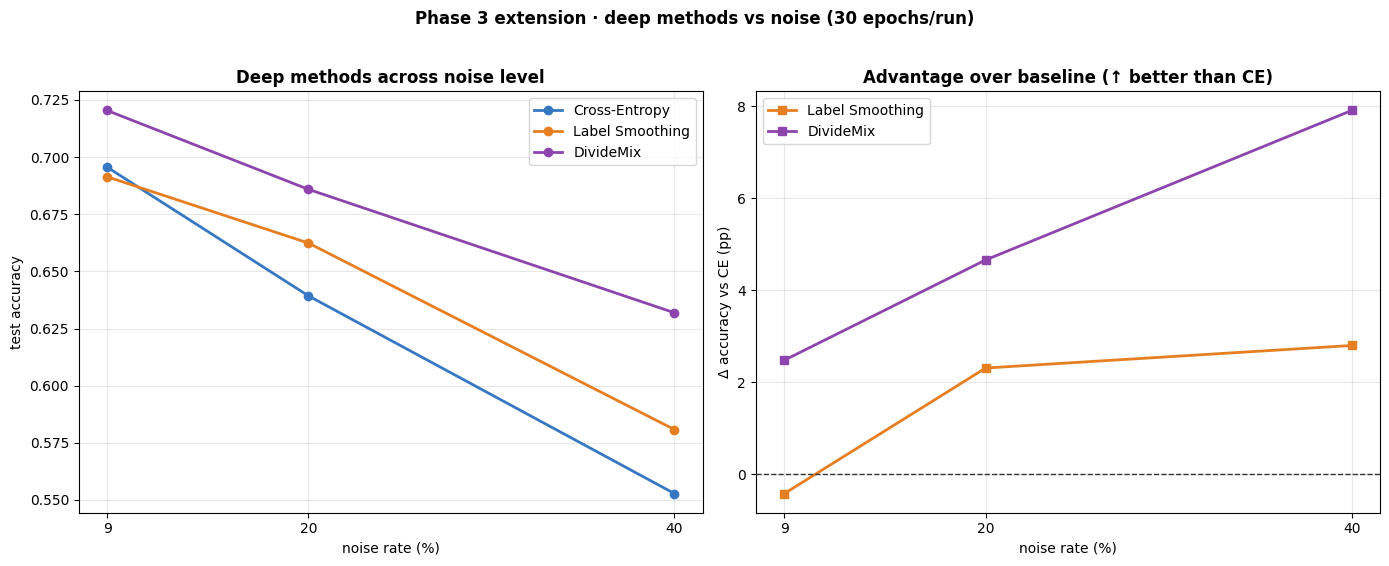

  ✓ saved fig_phase3_sweep.png


In [25]:

banner("FIGURE · Phase 3 sweep")
lv=[int(round(r*100)) for r in SWEEP_LEVELS]
cols={"Cross-Entropy":"#3778c2","Label Smoothing":"#e67e22","DivideMix":"#8e44ad"}
fig,(a1,a2)=plt.subplots(1,2,figsize=(14,5.5))
for name,c in cols.items():
    a1.plot(lv,[sweep3[r][name]["final"] for r in SWEEP_LEVELS],marker="o",lw=2,color=c,label=name)
a1.set_xlabel("noise rate (%)"); a1.set_ylabel("test accuracy")
a1.set_title("Deep methods across noise level",weight="bold"); a1.set_xticks(lv); a1.legend(); a1.grid(alpha=.3)
for name,c in [("Label Smoothing","#e67e22"),("DivideMix","#8e44ad")]:
    a2.plot(lv,[(sweep3[r][name]["final"]-sweep3[r]["Cross-Entropy"]["final"])*100 for r in SWEEP_LEVELS],
            marker="s",lw=2,color=c,label=name)
a2.axhline(0,color="#333",lw=1,ls="--")
a2.set_xlabel("noise rate (%)"); a2.set_ylabel("Δ accuracy vs CE (pp)")
a2.set_title("Advantage over baseline (↑ better than CE)",weight="bold"); a2.set_xticks(lv); a2.legend(); a2.grid(alpha=.3)
plt.suptitle(f"Phase 3 extension · deep methods vs noise ({SWEEP_EPOCHS} epochs/run)",weight="bold",y=1.02)
plt.tight_layout(); plt.savefig(CACHE/"fig_phase3_sweep.png",dpi=150,bbox_inches="tight"); plt.show()
ok("saved fig_phase3_sweep.png")

---
# Dissertation Findings — Summary

**Problem.** The field studies *symmetric* (random) label noise; real human noise is
*structured* and *instance-dependent*. Does structure change how models fail, and can it
be exploited?

**Phase 1 — human noise is structured.**
- Aggregating 3 annotators (each ~17% wrong) gives 9% noise; worst case 40%.
- Confusion is semantically local: truck→auto 7.3%, cat→dog 5.7% (symmetric would be ~1%).
- CIFAR-100: within-superclass errors are **8.6× above chance**.
- Two entropy regimes coexist (truck 0.79 concentrated ↔ bird 2.04 diffuse).

**Phase 2 — structure changes failure, and is exploitable (frozen features).**
- **Headline:** Fuzzy SVM beats SVM by **+1.26pp under 40% human noise (p=0.002)** but
  **+0.02pp under symmetric (p=0.78)** — it exploits *structure specifically*. Robust across
  9/9 hyperparameter settings.
- Structured−symmetric gap grows super-linearly: 0.9→2.5→12.8→**39.1pp** at 70%.
- Multi-metric: accuracy/F1 collapse, but **ROC-AUC holds** (0.93) and **calibration
  improves** — structure breaks the decision rule while sparing the representation.
- **Original analysis:** entropy fails to predict per-class harm (r=−0.02); **net flow**
  (direction of noise) works (r=+0.54) — automobile even *improves* by receiving mislabels.

**Phase 3 — deep learning, end-to-end.**
- Sample-selection methods win: **Co-teaching +3.99pp, DivideMix +4.36pp**.
- **Memorisation gradient:** 2.3→1.1→0.4→**0.0pp** — DivideMix never memorises.
- **Honest negative:** label smoothing *hurts* (−1.43pp) at low noise.
- DivideMix's GMM over-flags (0.86 vs 0.91) — the fingerprint of structured noise.

**Cross-phase — the deepest finding.** Frozen features (~90% @ 40%) vs end-to-end
(~70% @ 9%): the **~20pp gap quantifies how much clean-pretrained features protect against
noise**. Robustness depends more on representation quality than classifier choice.

**Why class-conditional, not full instance-dependent noise?** Real noise has two layers:
*which classes* confuse (captured by the transition matrix — injected) and *which images*
within a class (instance-level — approximated). We isolate the first because it is the
dominant departure from symmetric noise and gives a *controlled* comparison. The honest
claim is about class-conditional structured noise; genuine instance-dependence (using
CIFAR-N's per-annotator labels) is the main future direction, and would likely *strengthen*
the effect since ambiguous images are where the Fuzzy neighbourhood signal is strongest.

**The contribution in one sentence.** Structured human noise is not merely *harder* than
the symmetric noise the field studies — it is *exploitable*, which the symmetric paradigm
cannot reveal.

**Limitations.** Class-conditional (not full instance-dependent) noise; Phase 3 single seed;
DivideMix simplified (no MixMatch); net-flow predictor at n=10 needs CIFAR-100 to confirm.

**Improvements open.** Deep methods across noise levels; multi-seed Phase 3; genuine
instance-dependent noise; net-flow on CIFAR-100.

In [26]:

# Save everything so you never re-run. Download the printed zip from the Output panel.
def make_backup():
    import zipfile
    from datetime import datetime
    st=datetime.now().strftime("%Y%m%d_%H%M"); tmp="/kaggle/tmp_b"; os.makedirs(tmp,exist_ok=True)
    for f in os.listdir(CACHE):
        if (CACHE/f).is_file() and not f.endswith(".zip"): shutil.copy(CACHE/f,f"{tmp}/{f}")
    base=f"/kaggle/working/dissertation_cache_{st}"; shutil.make_archive(base,"zip",tmp); shutil.rmtree(tmp)
    ok(f"backup: dissertation_cache_{st}.zip ({os.path.getsize(base+'.zip')/1e6:.0f} MB) — download it now")
banner("BACKUP"); make_backup()


══════════════════════════════════════════════════════════════════════
  BACKUP
══════════════════════════════════════════════════════════════════════
  ✓ backup: dissertation_cache_20260824_1253.zip (144 MB) — download it now
